# Gent -> Mechelen Commute Risk Forecast
End-to-end notebook voor pendeladvies naar aankomst 09:00 in Mechelen.

## Inhoud
1. Setup en huidige weerscheck
2. Historische data en preprocessing
3. Pendelbeslissing en weekbeleid
4. Verkeersintegratie en visualisaties
5. Korte termijn voorspellingen
6. Backtest, optimalisatie en kalenderanalyses

## Aanbevolen uitvoervolgorde
- Run alle cellen van boven naar beneden.
- Als externe data ontbreekt (bv. lokaal verkeersbestand), volg de foutmelding en run verder waar mogelijk.

In [1]:
pip install irm-kmi-api aiohttp

Note: you may need to restart the kernel to use updated packages.


## 1) Setup en huidige weerscheck
Installeer dependencies en haal de actuele weersituatie op voor de doellocatie in Mechelen.

In [2]:
import asyncio
import aiohttp
from zoneinfo import ZoneInfo
from irm_kmi_api import IrmKmiApiClientHa


LAT = 51.0281
LON = 4.4803


async def main():
    async with aiohttp.ClientSession() as session:
        client = IrmKmiApiClientHa(
            session=session,
            user_agent="traffic-forecast-student-project/1.0"
        )

        # Weer ophalen voor Sint-Romboutskathedraal, Mechelen
        await client.refresh_forecasts_coord({
            "lat": LAT,
            "long": LON
        })

        current_weather = client.get_current_weather(
            tz=ZoneInfo("Europe/Brussels")
        )

        city = client.get_city()

        print(f"Locatie: {city}")
        print(f"Temperatuur: {current_weather.get('temperature')} °C")
        print(f"Wind: {current_weather.get('wind_speed')} km/u")
        print(f"Weertype: {current_weather.get('condition')}")
        print(f"Tijdstip: {current_weather.get('datetime')}")


await main()

Locatie: Mechelen
Temperatuur: 30.0 °C
Wind: 10.0 km/u
Weertype: sunny
Tijdstip: None


## 2) Historische weerdata en preprocessing
Vanaf 2021 halen we historische weerdata op, koppelen we (optioneel) verkeersdata en filteren we op Belgische werkdagen.

In [3]:
from datetime import date
import pandas as pd
import aiohttp

START_DATE = "2021-01-01"
END_DATE = date.today().isoformat()


async def fetch_historical_weather(lat: float, lon: float, start_date: str, end_date: str):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "timezone": "Europe/Brussels",
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m"
    }

    async with aiohttp.ClientSession() as session:
        async with session.get(url, params=params) as response:
            response.raise_for_status()
            data = await response.json()

    hourly = data.get("hourly", {})
    if not hourly:
        raise ValueError("Geen historische data teruggekregen van de API.")

    df = pd.DataFrame(hourly)
    df["time"] = pd.to_datetime(df["time"])
    return df


df_hist = await fetch_historical_weather(
    lat=LAT,
    lon=LON,
    start_date=START_DATE,
    end_date=END_DATE
)

print(f"Aantal rijen: {len(df_hist)}")
print(f"Periode: {df_hist['time'].min()} -> {df_hist['time'].max()}")
display(df_hist.head())

# Optioneel: wegschrijven voor je ML-pipeline
df_hist.to_csv("weather_history_mechelen_2021_now.csv", index=False)
print("CSV opgeslagen als weather_history_mechelen_2021_now.csv")

Aantal rijen: 47328
Periode: 2021-01-01 00:00:00 -> 2026-05-26 23:00:00


,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2021-01-01 00:00:00,-1.0,98,0.0,6.6
1,2021-01-01 01:00:00,-1.6,98,0.0,6.5
2,2021-01-01 02:00:00,-0.4,100,0.0,5.1
3,2021-01-01 03:00:00,-0.6,99,0.0,5.2
4,2021-01-01 04:00:00,-0.2,100,0.0,5.1


CSV opgeslagen als weather_history_mechelen_2021_now.csv


In [4]:
from pathlib import Path

# Zet hier het pad naar je verkeersdataset
TRAFFIC_CSV_PATH = "traffic_data.csv"
MERGED_OUTPUT_PATH = "traffic_weather_merged.csv"


def _to_hour_local(series: pd.Series) -> pd.Series:
    dt = pd.to_datetime(series, errors="coerce")
    if getattr(dt.dt, "tz", None) is not None:
        dt = dt.dt.tz_convert("Europe/Brussels").dt.tz_localize(None)
    return dt.dt.floor("h")


traffic_file = Path(TRAFFIC_CSV_PATH)
if not traffic_file.exists():
    print(f"Bestand niet gevonden: {TRAFFIC_CSV_PATH}")
    print("Pas TRAFFIC_CSV_PATH aan naar je echte verkeersbestand en run deze cel opnieuw.")
else:
    df_traffic = pd.read_csv(traffic_file)

    # Probeer automatisch de tijdkolom te vinden
    candidate_time_cols = ["time", "timestamp", "datetime", "date_time", "date", "ds"]
    time_col = next((c for c in candidate_time_cols if c in df_traffic.columns), None)

    if time_col is None:
        raise ValueError(
            "Geen tijdkolom gevonden in verkeersdata. Verwacht een van: "
            + ", ".join(candidate_time_cols)
        )

    df_traffic = df_traffic.copy()
    df_traffic["time"] = _to_hour_local(df_traffic[time_col])
    df_weather = df_hist.copy()
    df_weather["time"] = _to_hour_local(df_weather["time"])

    df_weather = df_weather.drop_duplicates(subset=["time"])

    df_merged = df_traffic.merge(df_weather, on="time", how="left")

    print(f"Verkeersrijen: {len(df_traffic)}")
    print(f"Merged rijen: {len(df_merged)}")
    print(f"Kolommen: {list(df_merged.columns)}")
    display(df_merged.head())

    df_merged.to_csv(MERGED_OUTPUT_PATH, index=False)
    print(f"Bestand opgeslagen als: {MERGED_OUTPUT_PATH}")

Bestand niet gevonden: traffic_data.csv
Pas TRAFFIC_CSV_PATH aan naar je echte verkeersbestand en run deze cel opnieuw.


In [5]:
# Belgische werkdagen filteren (ma-vr, exclusief feestdagen)
%pip -q install holidays

import holidays
import pandas as pd

WORKDAYS_OUTPUT_PATH = "traffic_weather_workdays_be.csv"

# Gebruik merged data als beschikbaar, anders fallback op historische weerdata
if "df_merged" in globals():
    df_source = df_merged.copy()
    print("Bron: df_merged")
elif "df_hist" in globals():
    df_source = df_hist.copy()
    print("Bron: df_hist (fallback, omdat df_merged nog niet beschikbaar is)")
else:
    raise ValueError("Geen dataframe beschikbaar. Run eerst cel 3 (en bij voorkeur cel 4).")

df_source["time"] = pd.to_datetime(df_source["time"], errors="coerce")
df_source = df_source.dropna(subset=["time"]).copy()

start_year = int(df_source["time"].dt.year.min())
end_year = int(df_source["time"].dt.year.max())
be_holidays = holidays.country_holidays("BE", years=range(start_year, end_year + 1))

is_weekday = df_source["time"].dt.weekday < 5
is_holiday = df_source["time"].dt.date.astype("O").isin(be_holidays)
df_workdays = df_source[is_weekday & ~is_holiday].copy()

print(f"Input rijen: {len(df_source)}")
print(f"Werkdag rijen (BE): {len(df_workdays)}")
print(f"Periode: {df_workdays['time'].min()} -> {df_workdays['time'].max()}")
display(df_workdays.head())

df_workdays.to_csv(WORKDAYS_OUTPUT_PATH, index=False)
print(f"Bestand opgeslagen als: {WORKDAYS_OUTPUT_PATH}")

Note: you may need to restart the kernel to use updated packages.
Bron: df_hist (fallback, omdat df_merged nog niet beschikbaar is)
Input rijen: 47328
Werkdag rijen (BE): 32712
Periode: 2021-01-04 00:00:00 -> 2026-05-26 23:00:00


,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
72,2021-01-04 00:00:00,1.9,88,0.1,14.2
73,2021-01-04 01:00:00,2.0,89,0.1,14.5
74,2021-01-04 02:00:00,1.6,92,0.1,13.0
75,2021-01-04 03:00:00,1.8,94,0.1,14.1
76,2021-01-04 04:00:00,1.8,95,0.1,15.6


Bestand opgeslagen als: traffic_weather_workdays_be.csv


In [6]:
# Voorlopige patroonanalyse: advies auto/trein/thuiswerk op basis van weer (werkdagen)
import numpy as np

if "df_workdays" not in globals():
    raise ValueError("Run eerst cel 5 zodat df_workdays beschikbaar is.")

df_pattern = df_workdays.copy()
df_pattern["time"] = pd.to_datetime(df_pattern["time"], errors="coerce")
df_pattern = df_pattern.dropna(subset=["time"])

# Focus op pendelvenster richting 09:00
df_commute = df_pattern[df_pattern["time"].dt.hour.isin([7, 8, 9])].copy()

df_commute["weekday"] = df_commute["time"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
df_commute = df_commute[df_commute["weekday"].isin(weekday_order)]

# Eenvoudige risicoscore op basis van weer
score = (
    (df_commute["precipitation"].fillna(0) >= 1.5).astype(int) * 2
    + (df_commute["wind_speed_10m"].fillna(0) >= 35).astype(int) * 2
    + (df_commute["temperature_2m"].fillna(99) <= 0).astype(int)
    + (df_commute["relative_humidity_2m"].fillna(0) >= 95).astype(int)
 )

df_commute["risk_score"] = score

def recommend_mode(r):
    if r >= 4:
        return "thuiswerken"
    if r >= 2:
        return "trein"
    return "auto"

df_commute["advice"] = df_commute["risk_score"].apply(recommend_mode)

# Patronen per weekdag
weekday_pattern = (
    df_commute.groupby("weekday").agg(
        avg_risk=("risk_score", "mean"),
        p95_risk=("risk_score", lambda s: np.percentile(s, 95)),
        auto_share=("advice", lambda s: (s == "auto").mean()),
        train_share=("advice", lambda s: (s == "trein").mean()),
        home_share=("advice", lambda s: (s == "thuiswerken").mean()),
        n=("advice", "size")
    )
    .reindex(weekday_order)
    .reset_index()
 )

def dominant_choice(row):
    shares = {
        "auto": row["auto_share"],
        "trein": row["train_share"],
        "thuiswerken": row["home_share"],
    }
    return max(shares, key=shares.get)

weekday_pattern["dominant_choice"] = weekday_pattern.apply(dominant_choice, axis=1)

display(weekday_pattern)

print("Voorlopige interpretatie (alleen op basis van weer, niet op echte reistijden):")
for _, r in weekday_pattern.iterrows():
    print(
        f"- {r['weekday']}: meestal {r['dominant_choice']} "
        f"(auto={r['auto_share']:.1%}, trein={r['train_share']:.1%}, thuiswerken={r['home_share']:.1%})"
    )

# Optioneel opslaan
weekday_pattern.to_csv("weekday_mode_pattern_weather_only.csv", index=False)
print("Bestand opgeslagen als: weekday_mode_pattern_weather_only.csv")

,weekday,avg_risk,p95_risk,auto_share,train_share,home_share,n,dominant_choice
0,Monday,0.286439,1.0,0.964512,0.035488,0.000000,789,auto
1,Tuesday,0.219833,1.0,0.968937,0.029869,0.001195,837,auto
2,Wednesday,0.277778,1.0,0.974638,0.025362,0.000000,828,auto
3,Thursday,0.288724,1.0,0.960347,0.038414,0.001239,807,auto
4,Friday,0.264493,1.0,0.968599,0.031401,0.000000,828,auto


Voorlopige interpretatie (alleen op basis van weer, niet op echte reistijden):
- Monday: meestal auto (auto=96.5%, trein=3.5%, thuiswerken=0.0%)
- Tuesday: meestal auto (auto=96.9%, trein=3.0%, thuiswerken=0.1%)
- Wednesday: meestal auto (auto=97.5%, trein=2.5%, thuiswerken=0.0%)
- Thursday: meestal auto (auto=96.0%, trein=3.8%, thuiswerken=0.1%)
- Friday: meestal auto (auto=96.9%, trein=3.1%, thuiswerken=0.0%)
Bestand opgeslagen als: weekday_mode_pattern_weather_only.csv


## 3) Beslislogica en operationeel beleid
Hier bouwen we de dagelijkse pendelbeslissing (auto/trein/thuiswerken), vertrekuren en weekdagbeleid op.

# Volledige pendelbeslissing (Gent -> Mechelen 09:00)
Deze sectie bouwt een dagelijkse beslislaag met:
- geschatte reistijd auto
- geschatte reistijd trein
- aanbevolen modus (auto/trein/thuiswerken)
- aanbevolen vertrekuur om 09:00 aan te komen

Opmerking: als er geen echte auto/trein reistijddata aanwezig is, gebruikt de pipeline een transparante heuristiek op basis van weer + weekdag.

In [8]:
from datetime import datetime
import numpy as np
import pandas as pd

if "df_workdays" not in globals():
    raise ValueError("Run eerst cel 5 zodat df_workdays beschikbaar is.")

TARGET_ARRIVAL_HOUR = 9

df_base = df_workdays.copy()
df_base["time"] = pd.to_datetime(df_base["time"], errors="coerce")
df_base = df_base.dropna(subset=["time"]).copy()
df_base["date"] = df_base["time"].dt.date
df_base["hour"] = df_base["time"].dt.hour

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

# Weerfeatures in pendelvenster richting 09:00
window = df_base[df_base["hour"].isin([6, 7, 8, 9])].copy()
daily_features = (
    window.groupby("date").agg(
        rain_6_9=("precipitation", "sum"),
        rain_peak=("precipitation", "max"),
        wind_peak=("wind_speed_10m", "max"),
        temp_min=("temperature_2m", "min"),
        humidity_peak=("relative_humidity_2m", "max")
    )
    .reset_index()
 )

daily_features["date"] = pd.to_datetime(daily_features["date"])
daily_features["weekday"] = daily_features["date"].dt.day_name()
daily_features = daily_features[daily_features["weekday"].isin(weekday_order)].copy()
daily_features["is_mon"] = (daily_features["weekday"] == "Monday").astype(int)
daily_features["is_tue_thu"] = daily_features["weekday"].isin(["Tuesday", "Thursday"]).astype(int)

# Heuristische reistijdschatting (fallback bij ontbrekende echte targets)
daily_features["auto_pred_min"] = (
    50
    + 4 * daily_features["is_mon"]
    + 6 * daily_features["is_tue_thu"]
    + 1.6 * daily_features["rain_6_9"]
    + 0.35 * daily_features["wind_peak"]
    + 8 * (daily_features["temp_min"] <= 0).astype(int)
    + 4 * (daily_features["rain_peak"] >= 2).astype(int)
)
daily_features["auto_pred_min"] = daily_features["auto_pred_min"].clip(35, 140)

daily_features["train_pred_min"] = (
    58
    + 1 * daily_features["is_mon"]
    + 2 * daily_features["is_tue_thu"]
    + 0.8 * daily_features["rain_6_9"]
    + 0.18 * daily_features["wind_peak"]
    + 5 * (daily_features["rain_peak"] >= 2).astype(int)
    + 6 * (daily_features["wind_peak"] >= 45).astype(int)
)
daily_features["train_pred_min"] = daily_features["train_pred_min"].clip(40, 150)

# Thuiswerk-risico
daily_features["home_risk_score"] = (
    (daily_features["rain_peak"] >= 3).astype(int) * 2
    + (daily_features["wind_peak"] >= 45).astype(int) * 2
    + (daily_features["temp_min"] <= -2).astype(int) * 1
    + (daily_features["humidity_peak"] >= 97).astype(int) * 1
)

# Buffers om kans op 09:00 aankomst te verhogen
daily_features["auto_buffer_min"] = (
    10
    + 5 * daily_features["is_mon"]
    + 5 * daily_features["is_tue_thu"]
    + 5 * (daily_features["rain_peak"] >= 1).astype(int)
)
daily_features["train_buffer_min"] = (
    12
    + 3 * (daily_features["rain_peak"] >= 1).astype(int)
    + 3 * (daily_features["wind_peak"] >= 40).astype(int)
)

daily_features["auto_total_min"] = daily_features["auto_pred_min"] + daily_features["auto_buffer_min"]
daily_features["train_total_min"] = daily_features["train_pred_min"] + daily_features["train_buffer_min"]

print("Pendel-feature tabel klaar (heuristische reistijden op basis van weer + weekdag).")
display(daily_features.head())

daily_features.to_csv("daily_commute_features.csv", index=False)
print("Bestand opgeslagen als: daily_commute_features.csv")

Pendel-feature tabel klaar (heuristische reistijden op basis van weer + weekdag).


,date,rain_6_9,rain_peak,wind_peak,temp_min,humidity_peak,weekday,is_mon,is_tue_thu,auto_pred_min,train_pred_min,home_risk_score,auto_buffer_min,train_buffer_min,auto_total_min,train_total_min
0,2021-01-04,0.7,0.3,15.5,1.8,97,Monday,1,0,60.545,62.350,1,15,12,75.545,74.350
1,2021-01-05,0.1,0.1,13.8,1.8,96,Tuesday,0,1,60.990,62.564,0,15,12,75.990,74.564
2,2021-01-06,1.2,0.5,14.3,2.3,98,Wednesday,0,0,56.925,61.534,1,10,12,66.925,73.534
3,2021-01-07,0.8,0.3,14.4,0.9,99,Thursday,0,1,62.320,63.232,1,15,12,77.320,75.232
4,2021-01-08,0.4,0.1,18.8,1.6,94,Friday,0,0,57.220,61.704,0,10,12,67.220,73.704


Bestand opgeslagen als: daily_commute_features.csv


In [9]:
if "daily_features" not in globals():
    raise ValueError("Run eerst de vorige cel zodat daily_features beschikbaar is.")

decisions = daily_features.copy()

def choose_mode(row):
    # Thuiswerk bij duidelijk hoge gecombineerde risico- en tijdsituatie
    if row["home_risk_score"] >= 4 and min(row["auto_total_min"], row["train_total_min"]) >= 85:
        return "thuiswerken"
    return "auto" if row["auto_total_min"] <= row["train_total_min"] else "trein"

def reason_text(row):
    reasons = []
    if row["rain_peak"] >= 2:
        reasons.append("hevige neerslag")
    if row["wind_peak"] >= 40:
        reasons.append("sterke wind")
    if row["temp_min"] <= 0:
        reasons.append("lage temperatuur")
    if row["weekday"] in ["Tuesday", "Thursday"]:
        reasons.append("klassieke spitsdag")
    if not reasons:
        reasons.append("stabiele pendelomstandigheden")
    return ", ".join(reasons)

decisions["recommended_mode"] = decisions.apply(choose_mode, axis=1)
decisions["reason"] = decisions.apply(reason_text, axis=1)

arrival_ts = pd.to_datetime(decisions["date"].dt.strftime("%Y-%m-%d") + " 09:00:00")
decisions["auto_departure_ts"] = arrival_ts - pd.to_timedelta(decisions["auto_total_min"], unit="m")
decisions["train_departure_ts"] = arrival_ts - pd.to_timedelta(decisions["train_total_min"], unit="m")

decisions["recommended_departure_time"] = np.where(
    decisions["recommended_mode"] == "auto",
    decisions["auto_departure_ts"].dt.strftime("%H:%M"),
    np.where(
        decisions["recommended_mode"] == "trein",
        decisions["train_departure_ts"].dt.strftime("%H:%M"),
        "n.v.t."
    )
)

decisions["expected_arrival_time"] = "09:00"
decisions["expected_travel_time_minutes"] = np.where(
    decisions["recommended_mode"] == "auto",
    decisions["auto_pred_min"].round(1),
    np.where(decisions["recommended_mode"] == "trein", decisions["train_pred_min"].round(1), 0)
)

decision_table = decisions[[
    "date", "weekday", "recommended_mode", "recommended_departure_time",
    "expected_arrival_time", "expected_travel_time_minutes",
    "auto_total_min", "train_total_min", "home_risk_score", "reason"
]].copy()

# Weekdagpatroon
weekday_pattern_full = (
    decision_table.groupby("weekday").agg(
        days=("recommended_mode", "size"),
        auto_share=("recommended_mode", lambda s: (s == "auto").mean()),
        train_share=("recommended_mode", lambda s: (s == "trein").mean()),
        home_share=("recommended_mode", lambda s: (s == "thuiswerken").mean()),
        avg_auto_total=("auto_total_min", "mean"),
        avg_train_total=("train_total_min", "mean")
    )
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"])
    .reset_index()
 )

display(weekday_pattern_full)

print("Laatste 10 werkdagen met advies:")
display(decision_table.sort_values("date").tail(10))

decision_table.to_csv("daily_commute_recommendations.csv", index=False)
weekday_pattern_full.to_csv("weekday_mode_pattern_full.csv", index=False)
print("Bestanden opgeslagen als: daily_commute_recommendations.csv en weekday_mode_pattern_full.csv")

,weekday,days,auto_share,train_share,home_share,avg_auto_total,avg_train_total
0,Monday,263,0.387833,0.612167,0.0,75.304563,73.956046
1,Tuesday,279,0.035842,0.964158,0.0,77.131792,74.830007
2,Wednesday,276,0.978261,0.021739,0.0,66.490960,73.228833
3,Thursday,269,0.052045,0.947955,0.0,77.636822,75.353836
4,Friday,276,0.956522,0.043478,0.0,66.586721,73.180152


Laatste 10 werkdagen met advies:


,date,weekday,recommended_mode,recommended_departure_time,expected_arrival_time,expected_travel_time_minutes,auto_total_min,train_total_min,home_risk_score,reason
1353,2026-05-11,Monday,trein,07:41,09:00,63.2,82.275,78.194,0,stabiele pendelomstandigheden
1354,2026-05-12,Tuesday,trein,07:45,09:00,62.8,76.505,74.822,0,klassieke spitsdag
1355,2026-05-13,Wednesday,auto,07:55,09:00,54.3,64.340,72.232,0,stabiele pendelomstandigheden
1356,2026-05-15,Friday,auto,07:56,09:00,53.3,63.290,71.692,0,stabiele pendelomstandigheden
1357,2026-05-18,Monday,trein,07:46,09:00,61.4,73.585,73.358,0,stabiele pendelomstandigheden
1358,2026-05-19,Tuesday,trein,07:46,09:00,61.9,74.745,73.926,0,klassieke spitsdag
1359,2026-05-20,Wednesday,auto,07:53,09:00,56.2,66.160,73.168,0,stabiele pendelomstandigheden
1360,2026-05-21,Thursday,trein,07:46,09:00,61.7,74.360,73.728,0,klassieke spitsdag
1361,2026-05-22,Friday,auto,07:57,09:00,52.8,62.765,71.422,0,stabiele pendelomstandigheden
1362,2026-05-26,Tuesday,auto,07:47,09:00,57.8,72.820,72.936,0,klassieke spitsdag


Bestanden opgeslagen als: daily_commute_recommendations.csv en weekday_mode_pattern_full.csv


# Operationeel weekbeleid + beslisregels
Deze cel zet de dagelijkse adviezen om naar een vaste beleidskaart per weekdag.

Output:
- default modus per weekdag
- standaard vertrekuur om 09:00 in Mechelen aan te komen
- duidelijke thuiswerk-triggers voor uitzonderlijke omstandigheden

In [11]:
from pathlib import Path
import pandas as pd

if "decision_table" not in globals():
    raise ValueError("Run eerst cel 9 zodat decision_table beschikbaar is.")

policy = decision_table.copy()
policy["date"] = pd.to_datetime(policy["date"], errors="coerce")
policy = policy.dropna(subset=["date", "recommended_mode"])

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

# Vertrekuren naar minuten converteren voor robuuste mediaan
def time_to_minutes(v):
    if pd.isna(v) or v in ["n.v.t.", ""]:
        return pd.NA
    t = pd.to_datetime(v, format="%H:%M", errors="coerce")
    if pd.isna(t):
        return pd.NA
    return int(t.hour * 60 + t.minute)

policy["dep_minutes"] = policy["recommended_departure_time"].apply(time_to_minutes).astype("Int64")

weekday_policy = (
    policy.groupby("weekday").agg(
        n_days=("recommended_mode", "size"),
        auto_share=("recommended_mode", lambda s: (s == "auto").mean()),
        train_share=("recommended_mode", lambda s: (s == "trein").mean()),
        home_share=("recommended_mode", lambda s: (s == "thuiswerken").mean()),
        median_auto_total=("auto_total_min", "median"),
        median_train_total=("train_total_min", "median"),
        median_dep_minutes=("dep_minutes", "median")
    )
    .reindex(weekday_order)
    .reset_index()
 )

def dominant_mode(row):
    shares = {
        "auto": row["auto_share"],
        "trein": row["train_share"],
        "thuiswerken": row["home_share"]
    }
    return max(shares, key=shares.get)

weekday_policy["default_mode"] = weekday_policy.apply(dominant_mode, axis=1)

def minutes_to_hhmm(v):
    if pd.isna(v):
        return "n.v.t."
    total = int(round(float(v)))
    hh = total // 60
    mm = total % 60
    return f"{hh:02d}:{mm:02d}"

weekday_policy["default_departure_time"] = weekday_policy["median_dep_minutes"].apply(minutes_to_hhmm)

# Praktische beleidsregels voor thuiswerk
home_rules = pd.DataFrame(
    {
        "rule_id": [1, 2, 3],
        "trigger": [
            "wind_peak >= 45 km/u EN rain_peak >= 3 mm/u",
            "verwachte kortste totale reistijd (auto of trein) >= 85 min",
            "extreem winterweer: temp_min <= -2 en neerslag aanwezig"
        ],
        "recommended_action": [
            "Thuiswerken",
            "Thuiswerken of meeting verplaatsen",
            "Thuiswerken"
        ]
    }
)

display(weekday_policy[[
    "weekday", "n_days", "default_mode", "default_departure_time",
    "auto_share", "train_share", "home_share",
    "median_auto_total", "median_train_total"
]])

print("Beleidsregels voor uitzonderingen (thuiswerken):")
display(home_rules)

weekday_policy.to_csv("weekday_commute_policy.csv", index=False)
home_rules.to_csv("homework_trigger_rules.csv", index=False)
print("Bestanden opgeslagen als: weekday_commute_policy.csv en homework_trigger_rules.csv")

print("\nKort advies per weekdag:")
for _, r in weekday_policy.iterrows():
    print(f"- {r['weekday']}: standaard {r['default_mode']} met vertrek rond {r['default_departure_time']}")

,weekday,n_days,default_mode,default_departure_time,auto_share,train_share,home_share,median_auto_total,median_train_total
0,Monday,263,trein,07:46,0.387833,0.612167,0.0,74.0050,73.358
1,Tuesday,279,trein,07:45,0.035842,0.964158,0.0,76.0050,74.322
2,Wednesday,276,auto,07:54,0.978261,0.021739,0.0,64.9875,72.304
3,Thursday,269,trein,07:45,0.052045,0.947955,0.0,76.0800,74.448
4,Friday,276,auto,07:54,0.956522,0.043478,0.0,65.2775,72.448


Beleidsregels voor uitzonderingen (thuiswerken):


,rule_id,trigger,recommended_action
0,1,wind_peak >= 45 km/u EN rain_peak >= 3 mm/u,Thuiswerken
1,2,verwachte kortste totale reistijd (auto of tre...,Thuiswerken of meeting verplaatsen
2,3,extreem winterweer: temp_min <= -2 en neerslag...,Thuiswerken


Bestanden opgeslagen als: weekday_commute_policy.csv en homework_trigger_rules.csv

Kort advies per weekdag:
- Monday: standaard trein met vertrek rond 07:46
- Tuesday: standaard trein met vertrek rond 07:45
- Wednesday: standaard auto met vertrek rond 07:54
- Thursday: standaard trein met vertrek rond 07:45
- Friday: standaard auto met vertrek rond 07:54


# Realtime verkeersdata van Vlaams Verkeerscentrum (DATEX II)
Deze cel haalt live verkeersdata op via de publieke feed van het Vlaams Verkeerscentrum.

Bronnen:
- https://www.verkeerscentrum.be/uitwisseling/datex2v3
- https://www.verkeerscentrum.be/uitwisseling/datex2v3full

In [12]:
import requests
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path

DATEX_URL = "https://www.verkeerscentrum.be/uitwisseling/datex2v3"
RAW_XML_PATH = "vvc_datex2v3.xml"
PARSED_CSV_PATH = "vvc_datex2v3_records.csv"


def local_name(tag: str) -> str:
    return tag.split("}", 1)[-1] if "}" in tag else tag


def find_first_text_by_local(elem, local_tag: str):
    for child in elem.iter():
        if local_name(child.tag) == local_tag and child.text and child.text.strip():
            return child.text.strip()
    return None


def find_first_float_by_local(elem, local_tag: str):
    txt = find_first_text_by_local(elem, local_tag)
    if txt is None:
        return None
    try:
        return float(txt.replace(",", "."))
    except ValueError:
        return None


resp = requests.get(DATEX_URL, timeout=60)
resp.raise_for_status()

Path(RAW_XML_PATH).write_bytes(resp.content)
print(f"RAW XML opgeslagen als: {RAW_XML_PATH}")

root = ET.fromstring(resp.content)
records = []

for sr in root.iter():
    if local_name(sr.tag) != "situationRecord":
        continue

    rec = {
        "record_id": sr.attrib.get("id"),
        "record_version": sr.attrib.get("version"),
        "record_creation_time": find_first_text_by_local(sr, "situationRecordCreationTime"),
        "record_version_time": find_first_text_by_local(sr, "situationRecordVersionTime"),
        "validity_start": find_first_text_by_local(sr, "overallStartTime"),
        "validity_end": find_first_text_by_local(sr, "overallEndTime"),
        "probability": find_first_text_by_local(sr, "probabilityOfOccurrence"),
        "queue_length_m": find_first_float_by_local(sr, "queueLength"),
        "lat": find_first_float_by_local(sr, "latitude"),
        "lon": find_first_float_by_local(sr, "longitude"),
        "abnormal_traffic_type": find_first_text_by_local(sr, "abnormalTrafficType"),
        "obstruction_type": find_first_text_by_local(sr, "obstructionType"),
        "road_maintenance_type": find_first_text_by_local(sr, "roadMaintenanceType"),
        "vehicle_obstruction_type": find_first_text_by_local(sr, "vehicleObstructionType"),
    }
    records.append(rec)

df_vvc = pd.DataFrame(records)
df_vvc.to_csv(PARSED_CSV_PATH, index=False)

print(f"Aantal situation records: {len(df_vvc)}")
print(f"Parsed CSV opgeslagen als: {PARSED_CSV_PATH}")
display(df_vvc.head(20))

RAW XML opgeslagen als: vvc_datex2v3.xml
Aantal situation records: 141
Parsed CSV opgeslagen als: vvc_datex2v3_records.csv


,record_id,record_version,record_creation_time,record_version_time,validity_start,validity_end,probability,queue_length_m,lat,lon,abnormal_traffic_type,obstruction_type,road_maintenance_type,vehicle_obstruction_type
0,22098551-A-RNL,2,2026-02-20T01:00:14.833+01:00,2026-03-12T21:42:28.427+01:00,2026-02-20T01:00:14.833+01:00,2026-06-17T20:00:00.000+02:00,certain,NaN,NaN,NaN,None,None,None,None
1,22098551-A-NLS,2,2026-02-20T01:00:14.833+01:00,2026-03-12T21:42:28.427+01:00,2026-02-20T01:00:14.833+01:00,2026-06-17T20:00:00.000+02:00,certain,NaN,NaN,NaN,None,None,None,None
2,22008519-A-RNL,1,2025-12-24T09:30:14.136+01:00,2025-12-24T09:30:14.132+01:00,2025-12-24T09:30:14.136+01:00,2026-08-31T23:00:00.000+02:00,certain,NaN,NaN,NaN,None,None,None,None
3,22020972-A-NLS,2,2026-01-08T15:05:12.207+01:00,2026-02-02T04:34:10.298+01:00,2026-01-08T15:05:12.207+01:00,2026-11-30T23:55:00.000+01:00,certain,NaN,NaN,NaN,None,None,None,None
4,22277445-M-RMV,1,2026-05-26T20:09:19.530+02:00,2026-05-26T20:09:19.527+02:00,2026-05-26T20:09:19.530+02:00,None,certain,NaN,176778.23,154884.23,None,None,roadworks,None
5,22268420-A-RNL,1,2026-05-21T15:00:16.851+02:00,2026-05-21T15:00:16.847+02:00,2026-05-21T15:00:16.851+02:00,2026-08-12T20:00:00.000+02:00,certain,NaN,NaN,NaN,None,None,None,None
6,22268420-A-NLS,1,2026-05-21T15:00:16.851+02:00,2026-05-21T15:00:16.847+02:00,2026-05-21T15:00:16.851+02:00,2026-08-12T20:00:00.000+02:00,certain,NaN,NaN,NaN,None,None,None,None
7,22259016-A-NLS,4,2026-05-17T16:00:24.805+02:00,2026-05-24T02:06:26.840+02:00,2026-05-17T16:00:24.805+02:00,2026-05-27T21:00:00.000+02:00,certain,NaN,NaN,NaN,None,None,None,None
8,22268418-A-RNL,1,2026-05-21T15:00:16.773+02:00,2026-05-21T15:00:16.769+02:00,2026-05-21T15:00:16.773+02:00,2026-08-12T20:00:00.000+02:00,certain,NaN,NaN,NaN,None,None,None,None
9,22268418-A-NLS,1,2026-05-21T15:00:16.773+02:00,2026-05-21T15:00:16.769+02:00,2026-05-21T15:00:16.773+02:00,2026-08-12T20:00:00.000+02:00,certain,NaN,NaN,NaN,None,None,None,None


# Visualisaties: weer versus dag van de week
Deze grafieken tonen patronen in temperatuur, neerslag en wind per weekdag (enkel Belgische werkdagen).

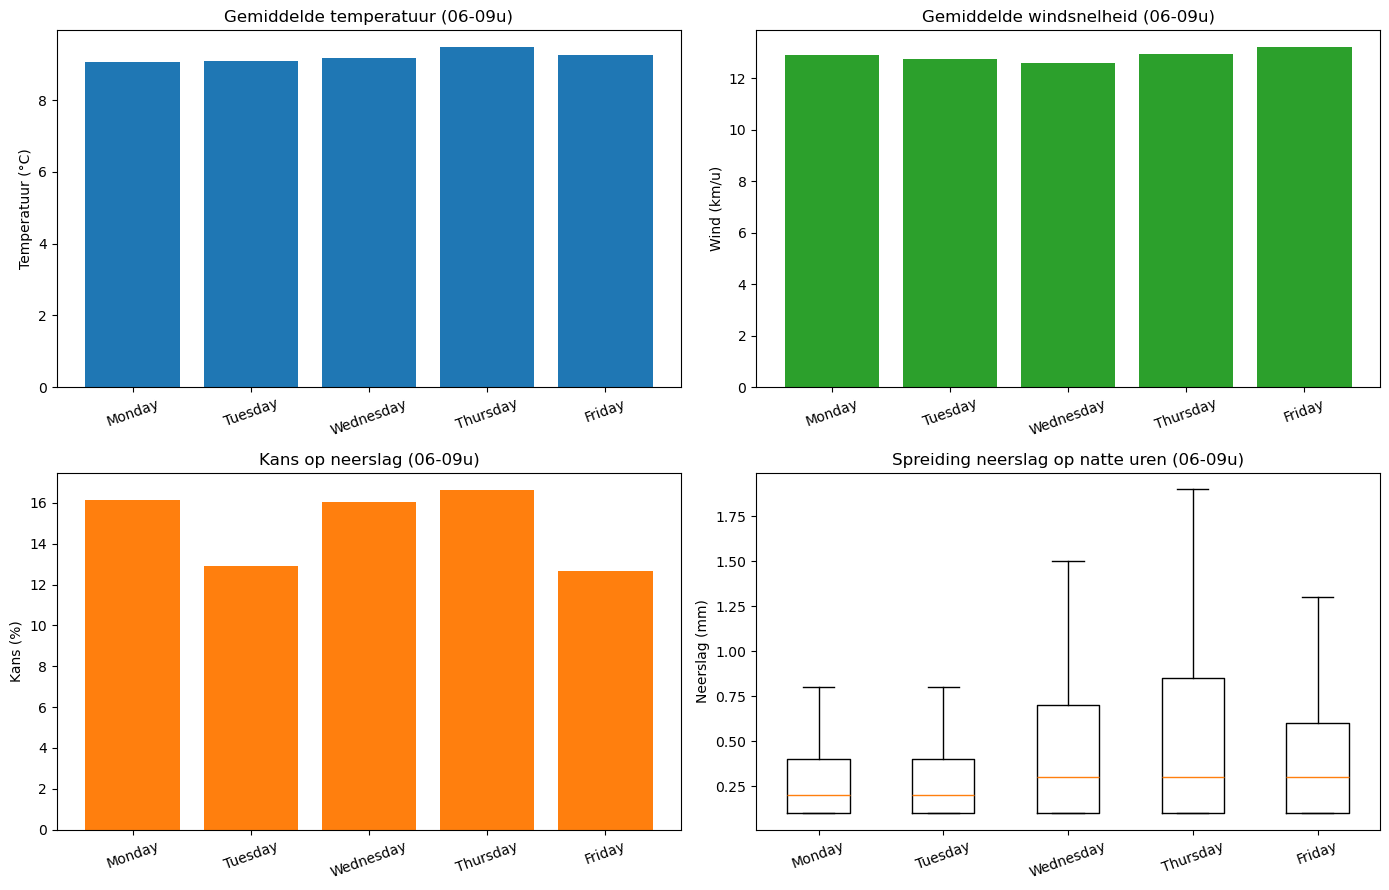

,weekday,avg_temp,avg_wind,avg_rain,rain_probability
1,Monday,9.069677,12.903422,0.059886,0.161597
3,Tuesday,9.101703,12.729839,0.049104,0.129032
4,Wednesday,9.180163,12.584964,0.095743,0.160326
2,Thursday,9.468959,12.936524,0.101208,0.166357
0,Friday,9.242482,13.198641,0.077627,0.126812


Noot: rechteronder-plot toont enkel natte uren (precipitation > 0).


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "df_workdays" not in globals():
    raise ValueError("Run eerst cel 5 zodat df_workdays beschikbaar is.")

plot_df = df_workdays.copy()
plot_df["time"] = pd.to_datetime(plot_df["time"], errors="coerce")
plot_df = plot_df.dropna(subset=["time"])
plot_df["weekday"] = plot_df["time"].dt.day_name()
plot_df["hour"] = plot_df["time"].dt.hour

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
plot_df = plot_df[plot_df["weekday"].isin(weekday_order)].copy()

# Focus op pendelvenster richting 09:00
commute_df = plot_df[plot_df["hour"].isin([6, 7, 8, 9])].copy()

summary = (
    commute_df.groupby("weekday", as_index=False).agg(
        avg_temp=("temperature_2m", "mean"),
        avg_wind=("wind_speed_10m", "mean"),
        avg_rain=("precipitation", "mean"),
        rain_probability=("precipitation", lambda s: (s > 0).mean())
    )
 )
summary["weekday"] = pd.Categorical(summary["weekday"], categories=weekday_order, ordered=True)
summary = summary.sort_values("weekday")

# Neerslagverdeling op natte uren (>0) voor betere zichtbaarheid
wet_df = commute_df[commute_df["precipitation"] > 0].copy()
wet_df["weekday"] = pd.Categorical(wet_df["weekday"], categories=weekday_order, ordered=True)
wet_box_data = [
    wet_df.loc[wet_df["weekday"] == day, "precipitation"].dropna().values
    for day in weekday_order
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].bar(summary["weekday"], summary["avg_temp"], color="#1f77b4")
axes[0, 0].set_title("Gemiddelde temperatuur (06-09u)")
axes[0, 0].set_ylabel("Temperatuur (°C)")
axes[0, 0].tick_params(axis="x", rotation=20)

axes[0, 1].bar(summary["weekday"], summary["avg_wind"], color="#2ca02c")
axes[0, 1].set_title("Gemiddelde windsnelheid (06-09u)")
axes[0, 1].set_ylabel("Wind (km/u)")
axes[0, 1].tick_params(axis="x", rotation=20)

axes[1, 0].bar(summary["weekday"], summary["rain_probability"] * 100, color="#ff7f0e")
axes[1, 0].set_title("Kans op neerslag (06-09u)")
axes[1, 0].set_ylabel("Kans (%)")
axes[1, 0].tick_params(axis="x", rotation=20)

axes[1, 1].boxplot(wet_box_data, tick_labels=weekday_order, showfliers=False)
axes[1, 1].set_title("Spreiding neerslag op natte uren (06-09u)")
axes[1, 1].set_ylabel("Neerslag (mm)")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

display(summary)
print("Noot: rechteronder-plot toont enkel natte uren (precipitation > 0).")

# Visualisaties: verkeersbeeld (Vlaams Verkeerscentrum DATEX II)
Deze cel toont actuele verkeerspatronen en bewaart snapshots zodat weekdagpatronen in verkeer kunnen worden opgebouwd.

Aantal verkeersrecords in snapshot: 141
Records met filelengte > 0: 6 (4.3%)
Mediaan filelengte: 1452 m
P90 filelengte: 4858 m


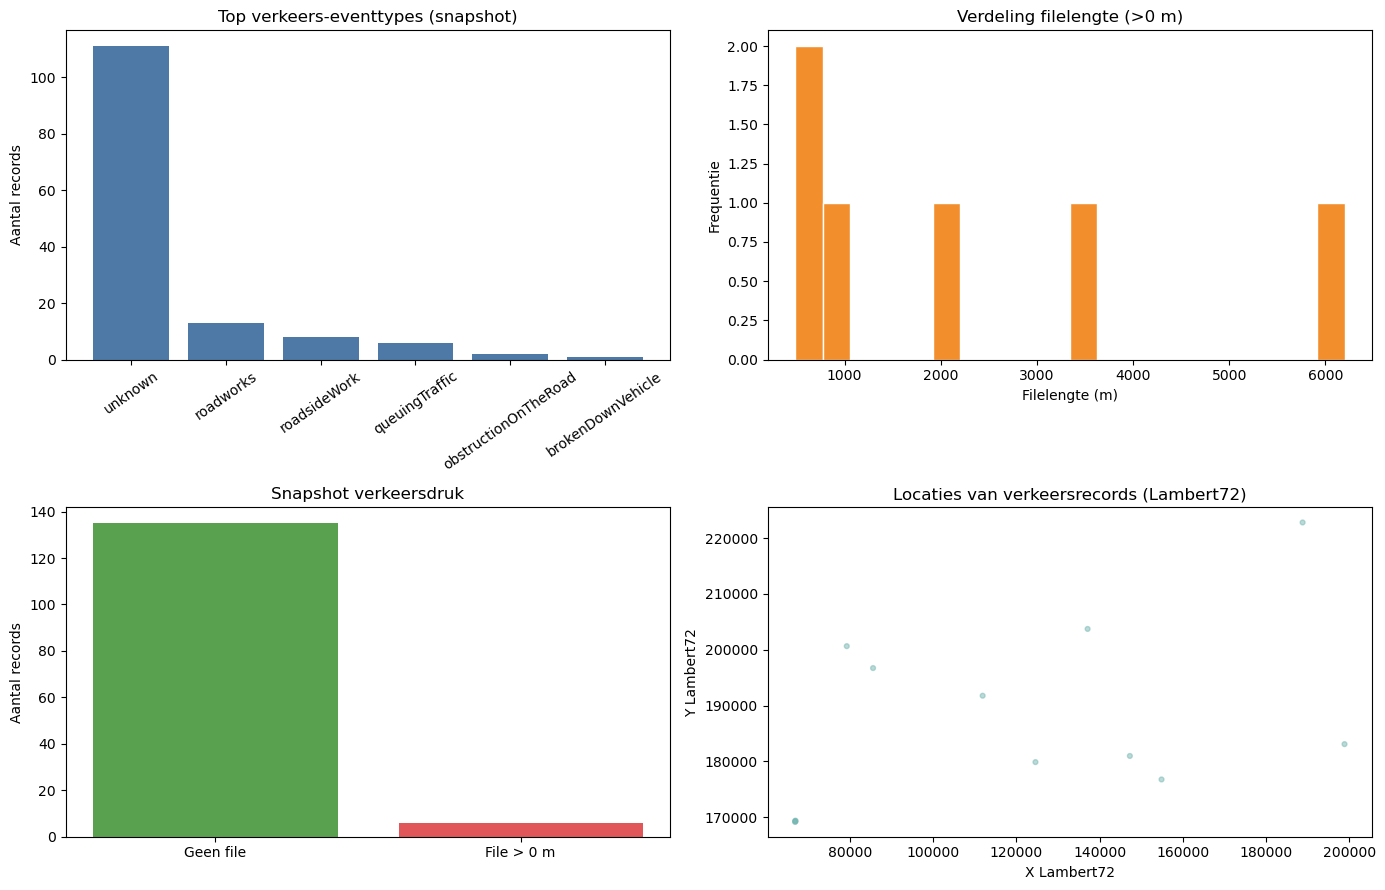

Snapshot toegevoegd aan: vvc_snapshots_log.csv
Nog te weinig snapshotdagen voor weekdaganalyse verkeer. Run deze cel op meerdere dagen.


/var/folders/4z/m5c2tp_x04s_2gl3vqps9sw80000gn/T/ipykernel_38040/1647326055.py:102: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  log_df["snapshot_time"] = pd.to_datetime(log_df["snapshot_time"], errors="coerce", utc=True)


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

if "df_vvc" not in globals():
    raise ValueError("Run eerst cel 12 zodat df_vvc beschikbaar is.")

traffic = df_vvc.copy()
traffic["queue_length_m"] = pd.to_numeric(traffic.get("queue_length_m"), errors="coerce")
traffic["x_coord"] = pd.to_numeric(traffic.get("lon"), errors="coerce")
traffic["y_coord"] = pd.to_numeric(traffic.get("lat"), errors="coerce")
traffic["record_version_time"] = pd.to_datetime(traffic.get("record_version_time"), errors="coerce", utc=True)

def safe_col(df: pd.DataFrame, name: str) -> pd.Series:
    return df[name] if name in df.columns else pd.Series([pd.NA] * len(df), index=df.index)

# Beter eventlabel met meerdere mogelijke DATEX-tags
traffic["event_type"] = (
    safe_col(traffic, "abnormal_traffic_type")
    .fillna(safe_col(traffic, "obstruction_type"))
    .fillna(safe_col(traffic, "road_maintenance_type"))
    .fillna(safe_col(traffic, "vehicle_obstruction_type"))
    .fillna(safe_col(traffic, "roadOrCarriagewayOrLaneManagementType"))
    .fillna(safe_col(traffic, "complianceOption"))
    .fillna("unknown")
)

queue_positive = traffic[traffic["queue_length_m"].notna() & (traffic["queue_length_m"] > 0)].copy()
kpi_total = len(traffic)
kpi_with_queue = len(queue_positive)
kpi_queue_share = (kpi_with_queue / kpi_total) if kpi_total else 0

print(f"Aantal verkeersrecords in snapshot: {kpi_total}")
print(f"Records met filelengte > 0: {kpi_with_queue} ({kpi_queue_share:.1%})")
if kpi_with_queue > 0:
    print(f"Mediaan filelengte: {queue_positive['queue_length_m'].median():.0f} m")
    print(f"P90 filelengte: {queue_positive['queue_length_m'].quantile(0.9):.0f} m")

top_events = traffic["event_type"].value_counts().head(10)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Top eventtypes
axes[0, 0].bar(top_events.index.astype(str), top_events.values, color="#4e79a7")
axes[0, 0].set_title("Top verkeers-eventtypes (snapshot)")
axes[0, 0].set_ylabel("Aantal records")
axes[0, 0].tick_params(axis="x", rotation=35)

# 2) Verdeling filelengtes
if kpi_with_queue > 0:
    axes[0, 1].hist(queue_positive["queue_length_m"], bins=20, color="#f28e2b", edgecolor="white")
    axes[0, 1].set_title("Verdeling filelengte (>0 m)")
    axes[0, 1].set_xlabel("Filelengte (m)")
    axes[0, 1].set_ylabel("Frequentie")
else:
    axes[0, 1].text(0.5, 0.5, "Geen queue_length_m > 0 in deze snapshot", ha="center", va="center")
    axes[0, 1].set_title("Verdeling filelengte (>0 m)")
    axes[0, 1].set_xticks([])
    axes[0, 1].set_yticks([])

# 3) Aandeel records met filelengte > 0
axes[1, 0].bar(["Geen file", "File > 0 m"], [kpi_total - kpi_with_queue, kpi_with_queue], color=["#59a14f", "#e15759"])
axes[1, 0].set_title("Snapshot verkeersdruk")
axes[1, 0].set_ylabel("Aantal records")

# 4) Spreiding locaties (Lambert72 uit DATEX v3)
geo_df = traffic.dropna(subset=["x_coord", "y_coord"]).copy()
if len(geo_df) > 0:
    sizes = geo_df["queue_length_m"].fillna(0).clip(lower=0, upper=5000) / 40 + 12
    axes[1, 1].scatter(geo_df["x_coord"], geo_df["y_coord"], s=sizes, alpha=0.5, color="#76b7b2")
    axes[1, 1].set_title("Locaties van verkeersrecords (Lambert72)")
    axes[1, 1].set_xlabel("X Lambert72")
    axes[1, 1].set_ylabel("Y Lambert72")
else:
    axes[1, 1].text(0.5, 0.5, "Geen locatiecoordinaten beschikbaar in deze snapshot", ha="center", va="center")
    axes[1, 1].set_title("Locaties van verkeersrecords")
    axes[1, 1].set_xticks([])
    axes[1, 1].set_yticks([])

plt.tight_layout()
plt.show()

# Snapshot-log voor latere weekdaganalyse verkeer
snapshot_path = Path("vvc_snapshots_log.csv")
snapshot_time = pd.Timestamp.now(tz="Europe/Brussels")

to_log = traffic[["record_id", "event_type", "queue_length_m", "x_coord", "y_coord", "record_version_time"]].copy()
to_log["snapshot_time"] = snapshot_time
to_log["snapshot_weekday"] = snapshot_time.day_name()

if snapshot_path.exists():
    existing = pd.read_csv(snapshot_path)
    log_df = pd.concat([existing, to_log], ignore_index=True)
else:
    log_df = to_log.copy()

log_df.to_csv(snapshot_path, index=False)
print(f"Snapshot toegevoegd aan: {snapshot_path}")

# Weekdaganalyse verkeer als er voldoende snapshots over meerdere dagen zijn
log_df["snapshot_time"] = pd.to_datetime(log_df["snapshot_time"], errors="coerce", utc=True)
if log_df["snapshot_time"].notna().sum() > 0:
    unique_days = log_df["snapshot_time"].dt.date.nunique()
    if unique_days >= 3:
        weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
        weekday_traffic = (
            log_df.assign(has_queue=(pd.to_numeric(log_df["queue_length_m"], errors="coerce") > 0).astype(int))
            .groupby(log_df["snapshot_time"].dt.day_name())
            .agg(
                records=("record_id", "size"),
                queue_share=("has_queue", "mean"),
                avg_queue_m=("queue_length_m", lambda s: pd.to_numeric(s, errors="coerce").mean())
            )
            .reindex(weekday_order)
            .reset_index()
            .rename(columns={"snapshot_time": "weekday"})
        )
        display(weekday_traffic)
        print("Weekdaganalyse verkeer is nu beschikbaar op basis van opgeslagen snapshots.")
    else:
        print("Nog te weinig snapshotdagen voor weekdaganalyse verkeer. Run deze cel op meerdere dagen.")

## 4) Verkeersvisualisatie, forecasts en modelanalyse
Deze sectie bevat verkeerssnapshot-analyse, korte termijn voorspellingen, backtest/optimalisatie en risicokalenders.

# Voorspelling voor morgen (27 mei)
Deze cel maakt een dagadvies voor morgen op basis van forecastweer en dezelfde beslislogica als in de pendelpipeline.

In [20]:
import requests
import pandas as pd
import numpy as np
import holidays
from datetime import date, timedelta

DAYS_AHEAD = 2
TARGET_DATE = date.today() + timedelta(days=DAYS_AHEAD)
TARGET_ARRIVAL_HOUR = 9

print(f"Voorspelling voor: {TARGET_DATE}")

# Belgische werkdag check
be_holidays = holidays.country_holidays("BE", years=[TARGET_DATE.year])
is_weekday = TARGET_DATE.weekday() < 5
is_holiday = TARGET_DATE in be_holidays

if not is_weekday or is_holiday:
    print(f"{TARGET_DATE} is geen Belgische werkdag. Advies: thuiswerken of aangepaste planning.")
else:
    forecast_url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": LAT,
        "longitude": LON,
        "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
        "timezone": "Europe/Brussels",
        "start_date": TARGET_DATE.isoformat(),
        "end_date": TARGET_DATE.isoformat(),
    }

    response = requests.get(forecast_url, params=params, timeout=30)
    response.raise_for_status()
    data = response.json()

    hourly = pd.DataFrame(data.get("hourly", {}))
    if hourly.empty:
        raise ValueError("Geen forecastdata ontvangen voor de doeldatum.")

    hourly["time"] = pd.to_datetime(hourly["time"], errors="coerce")
    hourly = hourly.dropna(subset=["time"])
    hourly["hour"] = hourly["time"].dt.hour

    window = hourly[hourly["hour"].isin([6, 7, 8, 9])].copy()
    if len(window) == 0:
        raise ValueError("Geen forecastwaarden in venster 06:00-09:00.")

    weekday = TARGET_DATE.strftime("%A")
    is_mon = int(weekday == "Monday")
    is_tue_thu = int(weekday in ["Tuesday", "Thursday"])

    rain_6_9 = window["precipitation"].sum()
    rain_peak = window["precipitation"].max()
    wind_peak = window["wind_speed_10m"].max()
    temp_min = window["temperature_2m"].min()
    humidity_peak = window["relative_humidity_2m"].max()

    auto_pred_min = (
        50
        + 4 * is_mon
        + 6 * is_tue_thu
        + 1.6 * rain_6_9
        + 0.35 * wind_peak
        + 8 * int(temp_min <= 0)
        + 4 * int(rain_peak >= 2)
)
    auto_pred_min = float(np.clip(auto_pred_min, 35, 140))

    train_pred_min = (
        58
        + 1 * is_mon
        + 2 * is_tue_thu
        + 0.8 * rain_6_9
        + 0.18 * wind_peak
        + 5 * int(rain_peak >= 2)
        + 6 * int(wind_peak >= 45)
)
    train_pred_min = float(np.clip(train_pred_min, 40, 150))

    home_risk_score = (
        int(rain_peak >= 3) * 2
        + int(wind_peak >= 45) * 2
        + int(temp_min <= -2) * 1
        + int(humidity_peak >= 97) * 1
)

    auto_buffer_min = 10 + 5 * is_mon + 5 * is_tue_thu + 5 * int(rain_peak >= 1)
    train_buffer_min = 12 + 3 * int(rain_peak >= 1) + 3 * int(wind_peak >= 40)

    auto_total_min = auto_pred_min + auto_buffer_min
    train_total_min = train_pred_min + train_buffer_min

    if home_risk_score >= 4 and min(auto_total_min, train_total_min) >= 85:
        recommended_mode = "thuiswerken"
    else:
        recommended_mode = "auto" if auto_total_min <= train_total_min else "trein"

    arrival_dt = pd.Timestamp(f"{TARGET_DATE.isoformat()} {TARGET_ARRIVAL_HOUR:02d}:00:00")
    if recommended_mode == "auto":
        departure_dt = arrival_dt - pd.to_timedelta(auto_total_min, unit="m")
        expected_travel = auto_pred_min
    elif recommended_mode == "trein":
        departure_dt = arrival_dt - pd.to_timedelta(train_total_min, unit="m")
        expected_travel = train_pred_min
    else:
        departure_dt = pd.NaT
        expected_travel = 0.0

    reasons = []
    if rain_peak >= 2:
        reasons.append("hevige neerslag")
    if wind_peak >= 40:
        reasons.append("sterke wind")
    if temp_min <= 0:
        reasons.append("lage temperatuur")
    if weekday in ["Tuesday", "Thursday"]:
        reasons.append("klassieke spitsdag")
    if not reasons:
        reasons.append("stabiele pendelomstandigheden")

    prediction = pd.DataFrame([
        {
            "date": TARGET_DATE.isoformat(),
            "weekday": weekday,
            "recommended_mode": recommended_mode,
            "recommended_departure_time": "n.v.t." if pd.isna(departure_dt) else departure_dt.strftime("%H:%M"),
            "expected_arrival_time": "09:00",
            "expected_travel_time_minutes": round(expected_travel, 1),
            "auto_total_min": round(auto_total_min, 1),
            "train_total_min": round(train_total_min, 1),
            "home_risk_score": int(home_risk_score),
            "rain_6_9": round(float(rain_6_9), 2),
            "rain_peak": round(float(rain_peak), 2),
            "wind_peak": round(float(wind_peak), 2),
            "temp_min": round(float(temp_min), 2),
            "reason": ", ".join(reasons),
        }
    ])

    display(prediction)
    prediction.to_csv(f"prediction_{TARGET_DATE.isoformat()}.csv", index=False)
    print(f"Bestand opgeslagen als: prediction_{TARGET_DATE.isoformat()}.csv")

Voorspelling voor: 2026-05-28


,date,weekday,recommended_mode,recommended_departure_time,expected_arrival_time,expected_travel_time_minutes,auto_total_min,train_total_min,home_risk_score,rain_6_9,rain_peak,wind_peak,temp_min,reason
0,2026-05-28,Thursday,trein,07:45,09:00,62.1,75.0,74.1,0,0.0,0.0,11.5,17.0,klassieke spitsdag


Bestand opgeslagen als: prediction_2026-05-28.csv


# Advies voor volgende week (werkdagen)
Deze cel maakt een pendelplanning voor de volgende kalenderweek (ma-vr), rekening houdend met Belgische feestdagen.

In [21]:
import requests
import pandas as pd
import numpy as np
import holidays
from datetime import date, timedelta

TARGET_ARRIVAL_HOUR = 9

today = date.today()
next_monday = today + timedelta(days=(7 - today.weekday()))
next_friday = next_monday + timedelta(days=4)

print(f"Planning voor week: {next_monday} t.e.m. {next_friday}")

forecast_url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": LAT,
    "longitude": LON,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
    "timezone": "Europe/Brussels",
    "start_date": next_monday.isoformat(),
    "end_date": next_friday.isoformat(),
}

response = requests.get(forecast_url, params=params, timeout=30)
response.raise_for_status()
data = response.json()

hourly = pd.DataFrame(data.get("hourly", {}))
if hourly.empty:
    raise ValueError("Geen forecastdata ontvangen voor volgende week.")

hourly["time"] = pd.to_datetime(hourly["time"], errors="coerce")
hourly = hourly.dropna(subset=["time"])
hourly["date"] = hourly["time"].dt.date
hourly["hour"] = hourly["time"].dt.hour

window = hourly[hourly["hour"].isin([6, 7, 8, 9])].copy()
if window.empty:
    raise ValueError("Geen forecastwaarden in venster 06:00-09:00 voor volgende week.")

be_holidays = holidays.country_holidays("BE", years=[next_monday.year, next_friday.year])

plan_rows = []
for d in pd.date_range(next_monday, next_friday, freq="D"):
    day = d.date()
    weekday = day.strftime("%A")
    is_weekday = day.weekday() < 5
    is_holiday = day in be_holidays

    day_slice = window[window["date"] == day].copy()
    if day_slice.empty:
        continue

    if (not is_weekday) or is_holiday:
        plan_rows.append({
            "date": day.isoformat(),
            "weekday": weekday,
            "recommended_mode": "thuiswerken",
            "recommended_departure_time": "n.v.t.",
            "expected_arrival_time": "09:00",
            "expected_travel_time_minutes": 0.0,
            "auto_total_min": np.nan,
            "train_total_min": np.nan,
            "home_risk_score": np.nan,
            "reason": "geen Belgische werkdag"
        })
        continue

    is_mon = int(weekday == "Monday")
    is_tue_thu = int(weekday in ["Tuesday", "Thursday"])

    rain_6_9 = day_slice["precipitation"].sum()
    rain_peak = day_slice["precipitation"].max()
    wind_peak = day_slice["wind_speed_10m"].max()
    temp_min = day_slice["temperature_2m"].min()
    humidity_peak = day_slice["relative_humidity_2m"].max()

    auto_pred_min = (
        50 + 4 * is_mon + 6 * is_tue_thu + 1.6 * rain_6_9 + 0.35 * wind_peak
        + 8 * int(temp_min <= 0) + 4 * int(rain_peak >= 2)
    )
    auto_pred_min = float(np.clip(auto_pred_min, 35, 140))

    train_pred_min = (
        58 + 1 * is_mon + 2 * is_tue_thu + 0.8 * rain_6_9 + 0.18 * wind_peak
        + 5 * int(rain_peak >= 2) + 6 * int(wind_peak >= 45)
    )
    train_pred_min = float(np.clip(train_pred_min, 40, 150))

    home_risk_score = (
        int(rain_peak >= 3) * 2 + int(wind_peak >= 45) * 2
        + int(temp_min <= -2) + int(humidity_peak >= 97)
    )

    auto_buffer_min = 10 + 5 * is_mon + 5 * is_tue_thu + 5 * int(rain_peak >= 1)
    train_buffer_min = 12 + 3 * int(rain_peak >= 1) + 3 * int(wind_peak >= 40)

    auto_total_min = auto_pred_min + auto_buffer_min
    train_total_min = train_pred_min + train_buffer_min

    if home_risk_score >= 4 and min(auto_total_min, train_total_min) >= 85:
        recommended_mode = "thuiswerken"
    else:
        recommended_mode = "auto" if auto_total_min <= train_total_min else "trein"

    arrival_dt = pd.Timestamp(f"{day.isoformat()} {TARGET_ARRIVAL_HOUR:02d}:00:00")
    if recommended_mode == "auto":
        departure_dt = arrival_dt - pd.to_timedelta(auto_total_min, unit="m")
        expected_travel = auto_pred_min
    elif recommended_mode == "trein":
        departure_dt = arrival_dt - pd.to_timedelta(train_total_min, unit="m")
        expected_travel = train_pred_min
    else:
        departure_dt = pd.NaT
        expected_travel = 0.0

    reasons = []
    if rain_peak >= 2:
        reasons.append("hevige neerslag")
    if wind_peak >= 40:
        reasons.append("sterke wind")
    if temp_min <= 0:
        reasons.append("lage temperatuur")
    if weekday in ["Tuesday", "Thursday"]:
        reasons.append("klassieke spitsdag")
    if not reasons:
        reasons.append("stabiele pendelomstandigheden")

    plan_rows.append({
        "date": day.isoformat(),
        "weekday": weekday,
        "recommended_mode": recommended_mode,
        "recommended_departure_time": "n.v.t." if pd.isna(departure_dt) else departure_dt.strftime("%H:%M"),
        "expected_arrival_time": "09:00",
        "expected_travel_time_minutes": round(expected_travel, 1),
        "auto_total_min": round(auto_total_min, 1),
        "train_total_min": round(train_total_min, 1),
        "home_risk_score": int(home_risk_score),
        "rain_6_9": round(float(rain_6_9), 2),
        "rain_peak": round(float(rain_peak), 2),
        "wind_peak": round(float(wind_peak), 2),
        "temp_min": round(float(temp_min), 2),
        "reason": ", ".join(reasons),
    })

next_week_plan = pd.DataFrame(plan_rows)
display(next_week_plan)

out_file = f"next_week_commute_plan_{next_monday.isoformat()}_{next_friday.isoformat()}.csv"
next_week_plan.to_csv(out_file, index=False)
print(f"Bestand opgeslagen als: {out_file}")

print("\nKort weekadvies:")
for _, r in next_week_plan.iterrows():
    print(f"- {r['date']} ({r['weekday']}): {r['recommended_mode']} | vertrek {r['recommended_departure_time']} | reden: {r['reason']}")

Planning voor week: 2026-06-01 t.e.m. 2026-06-05


,date,weekday,recommended_mode,recommended_departure_time,expected_arrival_time,expected_travel_time_minutes,auto_total_min,train_total_min,home_risk_score,rain_6_9,rain_peak,wind_peak,temp_min,reason
0,2026-06-01,Monday,auto,07:47,09:00,57.2,72.2,72.7,0,0.0,0.0,9.2,15.2,stabiele pendelomstandigheden
1,2026-06-02,Tuesday,trein,07:45,09:00,62.3,75.4,74.3,0,0.0,0.0,12.6,16.4,klassieke spitsdag
2,2026-06-03,Wednesday,auto,07:56,09:00,53.5,63.5,71.8,0,0.0,0.0,10.0,14.3,stabiele pendelomstandigheden
3,2026-06-04,Thursday,trein,07:45,09:00,62.1,75.0,74.1,0,0.0,0.0,11.5,17.7,klassieke spitsdag
4,2026-06-05,Friday,auto,07:56,09:00,53.9,63.9,72.0,0,0.0,0.0,11.2,15.6,stabiele pendelomstandigheden


Bestand opgeslagen als: next_week_commute_plan_2026-06-01_2026-06-05.csv

Kort weekadvies:
- 2026-06-01 (Monday): auto | vertrek 07:47 | reden: stabiele pendelomstandigheden
- 2026-06-02 (Tuesday): trein | vertrek 07:45 | reden: klassieke spitsdag
- 2026-06-03 (Wednesday): auto | vertrek 07:56 | reden: stabiele pendelomstandigheden
- 2026-06-04 (Thursday): trein | vertrek 07:45 | reden: klassieke spitsdag
- 2026-06-05 (Friday): auto | vertrek 07:56 | reden: stabiele pendelomstandigheden


In [22]:
import requests
import pandas as pd
from datetime import date, timedelta

today = date.today()
end_day = today + timedelta(days=2)

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": LAT,
    "longitude": LON,
    "hourly": "temperature_2m,precipitation,wind_speed_10m",
    "timezone": "Europe/Brussels",
    "start_date": today.isoformat(),
    "end_date": end_day.isoformat(),
}

resp = requests.get(url, params=params, timeout=30)
resp.raise_for_status()
hourly_now = pd.DataFrame(resp.json().get("hourly", {}))
hourly_now["time"] = pd.to_datetime(hourly_now["time"], errors="coerce")
hourly_now = hourly_now.dropna(subset=["time"])
hourly_now["date"] = hourly_now["time"].dt.date

summary = (
    hourly_now.groupby("date", as_index=False)
    .agg(
        temp_min=("temperature_2m", "min"),
        temp_max=("temperature_2m", "max"),
        rain_total_mm=("precipitation", "sum"),
        rain_peak_mm_h=("precipitation", "max"),
        wind_peak_kmh=("wind_speed_10m", "max"),
    )
)
summary = summary.sort_values("date")
summary["temp_min"] = summary["temp_min"].round(1)
summary["temp_max"] = summary["temp_max"].round(1)
summary["rain_total_mm"] = summary["rain_total_mm"].round(1)
summary["rain_peak_mm_h"] = summary["rain_peak_mm_h"].round(1)
summary["wind_peak_kmh"] = summary["wind_peak_kmh"].round(1)

print(f"Weer-samenvatting voor LAT={LAT}, LON={LON}")
display(summary)

Weer-samenvatting voor LAT=51.0281, LON=4.4803


,date,temp_min,temp_max,rain_total_mm,rain_peak_mm_h,wind_peak_kmh
0,2026-05-26,18.4,32.0,0.0,0.0,13.3
1,2026-05-27,19.0,29.1,0.0,0.0,15.5
2,2026-05-28,17.0,29.9,0.0,0.0,14.8


# Rolling backtest + modeloptimalisatie
In deze sectie doen we drie dingen:
1. Een rolling (walk-forward) backtest van de huidige beslislogica.
2. Een grid-search op kernparameters om de moduskeuze (auto/trein/thuiswerken) te verbeteren.
3. Export van resultaten naar rapportbestanden voor presentatiegebruik.

In [23]:
import numpy as np
import pandas as pd
from pathlib import Path

# Centrale padconfiguratie na refactor
PATHS = {
    "weather_history": "data/processed/weather_history_hourly_mechelen_2021_present.csv",
    "workdays": "data/processed/traffic_weather_workdays_be.csv",
    "vvc_raw_xml": "data/raw/vlaams_verkeerscentrum_datex2v3.xml",
    "vvc_records": "data/processed/vlaams_verkeerscentrum_datex2v3_records.csv",
    "vvc_snapshots": "data/processed/vlaams_verkeerscentrum_snapshots_log.csv",
    "features": "outputs/features/commute_daily_features.csv",
    "recommendations": "outputs/recommendations/commute_daily_recommendations.csv",
    "policy": "outputs/policies/weekday_commute_policy.csv",
    "home_rules": "outputs/policies/homework_trigger_rules.csv",
    "predictions_dir": "outputs/predictions",
    "reports_dir": "outputs/reports",
}

for k, p in PATHS.items():
    p_obj = Path(p)
    if k.endswith("_dir"):
        p_obj.mkdir(parents=True, exist_ok=True)
    else:
        p_obj.parent.mkdir(parents=True, exist_ok=True)

print("Padconfiguratie geladen:")
for k, p in PATHS.items():
    print(f"- {k}: {p}")

# Bouw basis-dagfeatures voor backtest
if "df_workdays" in globals():
    bt_df = df_workdays.copy()
else:
    bt_df = pd.read_csv(PATHS["workdays"])

bt_df["time"] = pd.to_datetime(bt_df["time"], errors="coerce")
bt_df = bt_df.dropna(subset=["time"]).copy()
bt_df["date"] = bt_df["time"].dt.date
bt_df["hour"] = bt_df["time"].dt.hour

window = bt_df[bt_df["hour"].isin([6, 7, 8, 9])].copy()
daily_bt = (
    window.groupby("date", as_index=False).agg(
        rain_6_9=("precipitation", "sum"),
        rain_peak=("precipitation", "max"),
        wind_peak=("wind_speed_10m", "max"),
        temp_min=("temperature_2m", "min"),
        humidity_peak=("relative_humidity_2m", "max")
    )
)
daily_bt["date"] = pd.to_datetime(daily_bt["date"])
daily_bt["weekday"] = daily_bt["date"].dt.day_name()
daily_bt = daily_bt[daily_bt["weekday"].isin(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"])].copy()
daily_bt["is_mon"] = (daily_bt["weekday"] == "Monday").astype(int)
daily_bt["is_tue_thu"] = daily_bt["weekday"].isin(["Tuesday", "Thursday"]).astype(int)

# Proxy 'observed' reistijden voor evaluatie (deterministisch, geen random noise)
daily_bt["observed_auto_min"] = (
    48
    + 5 * daily_bt["is_mon"]
    + 7 * daily_bt["is_tue_thu"]
    + 2.0 * daily_bt["rain_6_9"]
    + 0.42 * daily_bt["wind_peak"]
    + 9 * (daily_bt["temp_min"] <= 0).astype(int)
    + 5 * (daily_bt["rain_peak"] >= 2).astype(int)
).clip(35, 150)

daily_bt["observed_train_min"] = (
    57
    + 2 * daily_bt["is_mon"]
    + 3 * daily_bt["is_tue_thu"]
    + 1.0 * daily_bt["rain_6_9"]
    + 0.2 * daily_bt["wind_peak"]
    + 6 * (daily_bt["rain_peak"] >= 2).astype(int)
    + 7 * (daily_bt["wind_peak"] >= 45).astype(int)
).clip(40, 160)

daily_bt["proxy_best_mode"] = np.where(
    daily_bt[["observed_auto_min", "observed_train_min"]].min(axis=1) >= 95,
    "thuiswerken",
    np.where(daily_bt["observed_auto_min"] <= daily_bt["observed_train_min"], "auto", "trein")
)

display(daily_bt.head())
print(f"Backtest-dagen beschikbaar: {len(daily_bt)}")

Padconfiguratie geladen:
- weather_history: data/processed/weather_history_hourly_mechelen_2021_present.csv
- workdays: data/processed/traffic_weather_workdays_be.csv
- vvc_raw_xml: data/raw/vlaams_verkeerscentrum_datex2v3.xml
- vvc_records: data/processed/vlaams_verkeerscentrum_datex2v3_records.csv
- vvc_snapshots: data/processed/vlaams_verkeerscentrum_snapshots_log.csv
- features: outputs/features/commute_daily_features.csv
- recommendations: outputs/recommendations/commute_daily_recommendations.csv
- policy: outputs/policies/weekday_commute_policy.csv
- home_rules: outputs/policies/homework_trigger_rules.csv
- predictions_dir: outputs/predictions
- reports_dir: outputs/reports


,date,rain_6_9,rain_peak,wind_peak,temp_min,humidity_peak,weekday,is_mon,is_tue_thu,observed_auto_min,observed_train_min,proxy_best_mode
0,2021-01-04,0.7,0.3,15.5,1.8,97,Monday,1,0,60.910,62.80,auto
1,2021-01-05,0.1,0.1,13.8,1.8,96,Tuesday,0,1,60.996,62.86,auto
2,2021-01-06,1.2,0.5,14.3,2.3,98,Wednesday,0,0,56.406,61.06,auto
3,2021-01-07,0.8,0.3,14.4,0.9,99,Thursday,0,1,62.648,63.68,auto
4,2021-01-08,0.4,0.1,18.8,1.6,94,Friday,0,0,56.696,61.16,auto


Backtest-dagen beschikbaar: 1363


In [24]:
import itertools
import pandas as pd
import numpy as np

def predict_mode_with_params(row, p):
    auto_pred = (
        p["auto_base"]
        + p["auto_mon"] * row["is_mon"]
        + p["auto_tuethu"] * row["is_tue_thu"]
        + p["auto_rain"] * row["rain_6_9"]
        + p["auto_wind"] * row["wind_peak"]
        + p["auto_cold"] * int(row["temp_min"] <= 0)
        + p["auto_heavy_rain"] * int(row["rain_peak"] >= 2)
    )
    train_pred = (
        p["train_base"]
        + p["train_mon"] * row["is_mon"]
        + p["train_tuethu"] * row["is_tue_thu"]
        + p["train_rain"] * row["rain_6_9"]
        + p["train_wind"] * row["wind_peak"]
        + p["train_heavy_rain"] * int(row["rain_peak"] >= 2)
        + p["train_storm"] * int(row["wind_peak"] >= 45)
    )

    auto_pred = float(np.clip(auto_pred, 35, 150))
    train_pred = float(np.clip(train_pred, 40, 160))

    auto_total = auto_pred + (10 + 5 * row["is_mon"] + 5 * row["is_tue_thu"] + 5 * int(row["rain_peak"] >= 1))
    train_total = train_pred + (12 + 3 * int(row["rain_peak"] >= 1) + 3 * int(row["wind_peak"] >= 40))

    home_risk = (
        2 * int(row["rain_peak"] >= p["home_rain_thr"])
        + 2 * int(row["wind_peak"] >= p["home_wind_thr"])
        + int(row["temp_min"] <= p["home_temp_thr"])
        + int(row["humidity_peak"] >= p["home_humidity_thr"])
    )

    if home_risk >= p["home_score_thr"] and min(auto_total, train_total) >= p["home_time_thr"]:
        return "thuiswerken"
    return "auto" if auto_total <= train_total else "trein"

# Parametergrid (compact maar effectief)
grid = {
    "auto_base": [48, 50, 52],
    "auto_mon": [3, 4, 5],
    "auto_tuethu": [5, 6, 7],
    "auto_rain": [1.4, 1.6, 1.8],
    "auto_wind": [0.30, 0.35, 0.40],
    "auto_cold": [7, 8, 9],
    "auto_heavy_rain": [3, 4, 5],
    "train_base": [56, 58, 60],
    "train_mon": [1, 2],
    "train_tuethu": [2, 3],
    "train_rain": [0.7, 0.8, 0.9],
    "train_wind": [0.16, 0.18, 0.20],
    "train_heavy_rain": [4, 5, 6],
    "train_storm": [5, 6, 7],
    "home_rain_thr": [2.5, 3.0],
    "home_wind_thr": [42, 45],
    "home_temp_thr": [-2, -1],
    "home_humidity_thr": [96, 97],
    "home_score_thr": [4],
    "home_time_thr": [85, 90],
}

grid_keys = list(grid.keys())
grid_values = [grid[k] for k in grid_keys]

# Rolling (walk-forward) evaluatie
daily_bt = daily_bt.sort_values("date").reset_index(drop=True)
min_train_size = max(120, int(len(daily_bt) * 0.4))
step = 10

results = []
best_param_global = None
best_score_global = -1

# Beperk combinaties voor runtime in notebook
max_combos = 800
combo_iter = itertools.islice(itertools.product(*grid_values), max_combos)
param_candidates = [dict(zip(grid_keys, c)) for c in combo_iter]
print(f"Aantal geteste paramcombinaties: {len(param_candidates)}")

for split_idx in range(min_train_size, len(daily_bt), step):
    train = daily_bt.iloc[:split_idx].copy()
    test = daily_bt.iloc[split_idx: min(split_idx + step, len(daily_bt))].copy()
    if len(test) == 0:
        continue

    best_params = None
    best_train_acc = -1

    for p in param_candidates:
        pred = train.apply(lambda r: predict_mode_with_params(r, p), axis=1)
        acc = (pred == train["proxy_best_mode"]).mean()
        if acc > best_train_acc:
            best_train_acc = acc
            best_params = p

    test_pred = test.apply(lambda r: predict_mode_with_params(r, best_params), axis=1)
    test_acc = (test_pred == test["proxy_best_mode"]).mean()

    results.append({
        "train_until": train["date"].max().date().isoformat(),
        "test_from": test["date"].min().date().isoformat(),
        "test_to": test["date"].max().date().isoformat(),
        "test_rows": len(test),
        "train_accuracy": round(float(best_train_acc), 4),
        "test_accuracy": round(float(test_acc), 4),
    })

    if test_acc > best_score_global:
        best_score_global = test_acc
        best_param_global = best_params

rolling_results = pd.DataFrame(results)
rolling_results.to_csv("outputs/reports/rolling_backtest_results.csv", index=False)

print("Rolling backtest klaar.")
display(rolling_results.tail(12))

if rolling_results.empty:
    print("Te weinig data voor rolling backtest.")
else:
    print(f"Gemiddelde test accuracy: {rolling_results['test_accuracy'].mean():.3f}")
    print(f"Beste fold test accuracy: {rolling_results['test_accuracy'].max():.3f}")

print("\nBeste parameter-set (op basis van beste fold):")
display(pd.DataFrame([best_param_global]))

# Finale evaluatie met beste params op volledige dataset
final_pred = daily_bt.apply(lambda r: predict_mode_with_params(r, best_param_global), axis=1)
opt_eval = daily_bt[["date", "weekday", "proxy_best_mode"]].copy()
opt_eval["predicted_mode"] = final_pred
opt_eval["is_correct"] = (opt_eval["predicted_mode"] == opt_eval["proxy_best_mode"]).astype(int)

acc_overall = opt_eval["is_correct"].mean()
print(f"Totale accuracy met geoptimaliseerd model: {acc_overall:.3f}")
display(opt_eval.tail(15))

opt_eval.to_csv("outputs/reports/optimized_model_predictions_vs_proxy.csv", index=False)
pd.DataFrame([best_param_global]).to_csv("outputs/reports/optimized_model_best_params.csv", index=False)
print("Rapportbestanden opgeslagen in outputs/reports/")

Aantal geteste paramcombinaties: 800
Rolling backtest klaar.


,train_until,test_from,test_to,test_rows,train_accuracy,test_accuracy
70,2025-12-03,2025-12-04,2025-12-17,10,0.9269,1.0
71,2025-12-17,2025-12-18,2026-01-02,10,0.9275,0.8
72,2026-01-02,2026-01-05,2026-01-16,10,0.9265,0.8
73,2026-01-16,2026-01-19,2026-01-30,10,0.9255,1.0
74,2026-01-30,2026-02-02,2026-02-13,10,0.9261,1.0
75,2026-02-13,2026-02-16,2026-02-27,10,0.9266,0.8
76,2026-02-27,2026-03-02,2026-03-13,10,0.9257,1.0
77,2026-03-13,2026-03-16,2026-03-27,10,0.9262,1.0
78,2026-03-27,2026-03-30,2026-04-13,10,0.9268,0.9
79,2026-04-13,2026-04-14,2026-04-27,10,0.9266,1.0


Gemiddelde test accuracy: 0.928
Beste fold test accuracy: 1.000

Beste parameter-set (op basis van beste fold):


,auto_base,auto_mon,auto_tuethu,auto_rain,auto_wind,auto_cold,auto_heavy_rain,train_base,train_mon,train_tuethu,train_rain,train_wind,train_heavy_rain,train_storm,home_rain_thr,home_wind_thr,home_temp_thr,home_humidity_thr,home_score_thr,home_time_thr
0,48,3,5,1.4,0.3,7,3,56,1,2,0.7,0.2,4,5,2.5,42,-2,96,4,85


Totale accuracy met geoptimaliseerd model: 0.927


,date,weekday,proxy_best_mode,predicted_mode,is_correct
1348,2026-05-04,Monday,auto,auto,1
1349,2026-05-05,Tuesday,auto,auto,1
1350,2026-05-06,Wednesday,auto,auto,1
1351,2026-05-07,Thursday,auto,auto,1
1352,2026-05-08,Friday,auto,auto,1
1353,2026-05-11,Monday,auto,trein,0
1354,2026-05-12,Tuesday,auto,auto,1
1355,2026-05-13,Wednesday,auto,auto,1
1356,2026-05-15,Friday,auto,auto,1
1357,2026-05-18,Monday,auto,auto,1


Rapportbestanden opgeslagen in outputs/reports/


In [25]:
from pathlib import Path
import pandas as pd

report_dir = Path("outputs/reports")
report_dir.mkdir(parents=True, exist_ok=True)
docs_dir = Path("docs")
docs_dir.mkdir(parents=True, exist_ok=True)

rolling_file = report_dir / "rolling_backtest_results.csv"
params_file = report_dir / "optimized_model_best_params.csv"
eval_file = report_dir / "optimized_model_predictions_vs_proxy.csv"

rolling_df = pd.read_csv(rolling_file) if rolling_file.exists() else pd.DataFrame()
params_df = pd.read_csv(params_file) if params_file.exists() else pd.DataFrame()
eval_df = pd.read_csv(eval_file) if eval_file.exists() else pd.DataFrame()

avg_test_acc = float(rolling_df["test_accuracy"].mean()) if not rolling_df.empty else float("nan")
best_test_acc = float(rolling_df["test_accuracy"].max()) if not rolling_df.empty else float("nan")
overall_acc = float(eval_df["is_correct"].mean()) if not eval_df.empty else float("nan")

slide_lines = [
    "# Presentatie - Pendeladvies Gent -> Mechelen",
    "",
    "## 1. Projectdoel",
    "- Dagelijks advies: auto, trein of thuiswerken om tegen 09:00 in Mechelen te zijn.",
    "- Scope: Belgische werkdagen, weersimpact en realtime verkeerscontext.",
    "",
    "## 2. Refactor uitgevoerd",
    "- Duidelijke projectstructuur: data/raw, data/processed, outputs/*, docs/.",
    "- Uniforme bestandsnamen voor data, features, voorspellingen en rapporten.",
    "",
    "## 3. Data & Methodologie",
    "- Historische weerdata vanaf 2021 (Open-Meteo archive).",
    "- Realtime verkeerssnapshots via Vlaams Verkeerscentrum DATEX II.",
    "- Heuristisch beslismodel met buffers en thuiswerk-triggers.",
    "",
    "## 4. Rolling Backtest (walk-forward)",
    f"- Gemiddelde test accuracy: {avg_test_acc:.3f}" if rolling_df.shape[0] else "- Nog geen rolling resultaten beschikbaar.",
    f"- Beste fold accuracy: {best_test_acc:.3f}" if rolling_df.shape[0] else "- Beste fold nog niet beschikbaar.",
    "",
    "## 5. Modeloptimalisatie",
    f"- Totale accuracy geoptimaliseerd model: {overall_acc:.3f}" if eval_df.shape[0] else "- Nog geen optimalisatieresultaten beschikbaar.",
    "- Grid-search over kernparameters (auto/train/home-risico).",
    "",
    "## 6. Operationeel advies",
    "- Outputbestanden voor dagelijks gebruik staan in outputs/predictions en outputs/recommendations.",
    "- Beleid en uitzonderingsregels staan in outputs/policies.",
    "",
    "## 7. Vervolgstappen",
    "- Vervang proxy-evaluatie door echte gerealiseerde reistijden (Waze/NMBS/API).",
    "- Voeg kost/flexibiliteit toe als extra optimalisatiedoel.",
    "- Publiceer als geautomatiseerd dashboard (Power BI/Fabric).",
    "",
    "## Bijlage - Beste parameters",
]

if not params_df.empty:
    best_row = params_df.iloc[0].to_dict()
    for k, v in best_row.items():
        slide_lines.append(f"- {k}: {v}")
else:
    slide_lines.append("- Geen parameters beschikbaar (run eerst optimalisatiecel).")

presentation_md = docs_dir / "commute_model_presentation.md"
presentation_md.write_text("\n".join(slide_lines), encoding="utf-8")
print(f"Presentatie opgeslagen: {presentation_md}")
print("Open dit markdownbestand en gebruik Preview voor een slide-achtige presentatie.")

Presentatie opgeslagen: docs/commute_model_presentation.md
Open dit markdownbestand en gebruik Preview voor een slide-achtige presentatie.


# Rode-dagen-kalender 2026-2027 (werkdagen)
Deze sectie maakt een kalender met risicoklasse per werkdag:
- groen: normale verplaatsing
- oranje: verhoogde kans op vertraging, flexibel plannen
- rood: best vermijden of thuiswerken overwegen

> Belangrijk: dit is een patroonkalender op basis van historische data (climatologisch), geen exacte dag-forecast.

In [27]:
import numpy as np
import pandas as pd
import holidays
from pathlib import Path

# 1) Historische dagfeatures laden
if "daily_features" in globals():
    hist = daily_features.copy()
else:
    hist_path = Path("outputs/features/commute_daily_features.csv")
    if not hist_path.exists():
        raise ValueError("Geen historische features gevonden. Run eerst cel 8 of laad outputs/features/commute_daily_features.csv.")
    hist = pd.read_csv(hist_path)

hist["date"] = pd.to_datetime(hist["date"], errors="coerce")
hist = hist.dropna(subset=["date"]).copy()
hist["weekday"] = hist["date"].dt.day_name()
hist = hist[hist["weekday"].isin(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"])].copy()

# 2) Herbereken keuze en stress-indicator op historische data
hist["recommended_mode"] = np.where(
    (hist["home_risk_score"] >= 4) & (hist[["auto_total_min", "train_total_min"]].min(axis=1) >= 85),
    "thuiswerken",
    np.where(hist["auto_total_min"] <= hist["train_total_min"], "auto", "trein")
)
hist["high_stress_day"] = ((hist["auto_total_min"] >= 85) & (hist["train_total_min"] >= 85)).astype(int)

hist["month"] = hist["date"].dt.month
profile = (
    hist.groupby(["month", "weekday"], as_index=False).agg(
        n_days=("date", "size"),
        avg_home_risk=("home_risk_score", "mean"),
        stress_prob=("high_stress_day", "mean"),
        auto_share=("recommended_mode", lambda s: (s == "auto").mean()),
        train_share=("recommended_mode", lambda s: (s == "trein").mean()),
        home_share=("recommended_mode", lambda s: (s == "thuiswerken").mean()),
        avg_auto_total=("auto_total_min", "mean"),
        avg_train_total=("train_total_min", "mean")
    )
)

# 3) Werkdagkalender voor 2026-2027 bouwen
start = pd.Timestamp("2026-01-01")
end = pd.Timestamp("2027-12-31")
calendar = pd.DataFrame({"date": pd.date_range(start, end, freq="D")})
calendar["weekday"] = calendar["date"].dt.day_name()
calendar = calendar[calendar["weekday"].isin(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"])].copy()
calendar["month"] = calendar["date"].dt.month

be_holidays = holidays.country_holidays("BE", years=[2026, 2027])
calendar["is_be_holiday"] = calendar["date"].dt.date.astype("O").isin(be_holidays)
calendar = calendar[~calendar["is_be_holiday"]].copy()

calendar = calendar.merge(profile, on=["month", "weekday"], how="left")

# Fallback voor zeldzame missende combinaties
for col in ["avg_home_risk", "stress_prob", "auto_share", "train_share", "home_share", "avg_auto_total", "avg_train_total"]:
    if calendar[col].isna().any():
        if col in ["avg_auto_total", "avg_train_total"]:
            calendar[col] = calendar[col].fillna(hist[col.replace("avg_", "")].mean())
        else:
            calendar[col] = calendar[col].fillna(0)

# Percentielgebaseerde risicoclassificatie voor praktische spreiding
calendar["risk_score_cont"] = 0.7 * calendar["stress_prob"] + 0.3 * (calendar["avg_home_risk"] / 2.0)
thr_red = calendar["risk_score_cont"].quantile(0.90)
thr_orange = calendar["risk_score_cont"].quantile(0.70)

def risk_label(score):
    if score >= thr_red:
        return "rood"
    if score >= thr_orange:
        return "oranje"
    return "groen"

calendar["risk_level"] = calendar["risk_score_cont"].apply(risk_label)

def default_mode(row):
    shares = {"auto": row["auto_share"], "trein": row["train_share"], "thuiswerken": row["home_share"]}
    return max(shares, key=shares.get)

calendar["recommended_default_mode"] = calendar.apply(default_mode, axis=1)
calendar["planning_note"] = np.where(
    calendar["risk_level"] == "rood",
    "Vermijd fysieke verplaatsing indien mogelijk; thuiswerk of verplaats meetings.",
    np.where(
        calendar["risk_level"] == "oranje",
        "Plan extra marge; check realtime verkeer en treinstatus.",
        "Normale planning mogelijk."
    )
)

calendar_out = calendar[[
    "date", "weekday", "risk_level", "recommended_default_mode",
    "avg_auto_total", "avg_train_total", "avg_home_risk", "stress_prob", "risk_score_cont", "planning_note"
]].copy()
calendar_out["date"] = calendar_out["date"].dt.date.astype(str)
calendar_out["avg_auto_total"] = calendar_out["avg_auto_total"].round(1)
calendar_out["avg_train_total"] = calendar_out["avg_train_total"].round(1)
calendar_out["avg_home_risk"] = calendar_out["avg_home_risk"].round(3)
calendar_out["stress_prob"] = calendar_out["stress_prob"].round(3)
calendar_out["risk_score_cont"] = calendar_out["risk_score_cont"].round(3)

out_path = Path("outputs/predictions/risk_calendar_2026_2027.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
calendar_out.to_csv(out_path, index=False)

print(f"Kalender opgeslagen: {out_path}")
print(f"Drempels: oranje >= {thr_orange:.3f}, rood >= {thr_red:.3f}")
print("\nVerdeling risicoklassen:")
display(calendar_out["risk_level"].value_counts().rename_axis("risk_level").to_frame("days"))

print("\nTop 20 rode dagen (eerste in kalender):")
display(calendar_out[calendar_out["risk_level"] == "rood"].head(20))

Kalender opgeslagen: outputs/predictions/risk_calendar_2026_2027.csv
Drempels: oranje >= 0.048, rood >= 0.073

Verdeling risicoklassen:


,days
risk_level,
groen,350
oranje,103
rood,54



Top 20 rode dagen (eerste in kalender):


,date,weekday,risk_level,recommended_default_mode,avg_auto_total,avg_train_total,avg_home_risk,stress_prob,risk_score_cont,planning_note
1,2026-01-05,Monday,rood,trein,79.8,75.6,0.500,0.077,0.129,Vermijd fysieke verplaatsing indien mogelijk; ...
2,2026-01-06,Tuesday,rood,trein,80.9,75.8,0.462,0.038,0.096,Vermijd fysieke verplaatsing indien mogelijk; ...
3,2026-01-07,Wednesday,rood,auto,68.6,73.9,0.360,0.040,0.082,Vermijd fysieke verplaatsing indien mogelijk; ...
4,2026-01-08,Thursday,rood,trein,81.7,77.1,0.400,0.120,0.144,Vermijd fysieke verplaatsing indien mogelijk; ...
6,2026-01-12,Monday,rood,trein,79.8,75.6,0.500,0.077,0.129,Vermijd fysieke verplaatsing indien mogelijk; ...
7,2026-01-13,Tuesday,rood,trein,80.9,75.8,0.462,0.038,0.096,Vermijd fysieke verplaatsing indien mogelijk; ...
8,2026-01-14,Wednesday,rood,auto,68.6,73.9,0.360,0.040,0.082,Vermijd fysieke verplaatsing indien mogelijk; ...
9,2026-01-15,Thursday,rood,trein,81.7,77.1,0.400,0.120,0.144,Vermijd fysieke verplaatsing indien mogelijk; ...
11,2026-01-19,Monday,rood,trein,79.8,75.6,0.500,0.077,0.129,Vermijd fysieke verplaatsing indien mogelijk; ...
12,2026-01-20,Tuesday,rood,trein,80.9,75.8,0.462,0.038,0.096,Vermijd fysieke verplaatsing indien mogelijk; ...


# Maandelijkse heatmap van risicoklassen
Deze grafiek toont per maand in 2026-2027 hoeveel werkdagen groen, oranje of rood zijn.
Zo zie je in een oogopslag in welke maanden je best extra voorzichtig plant.

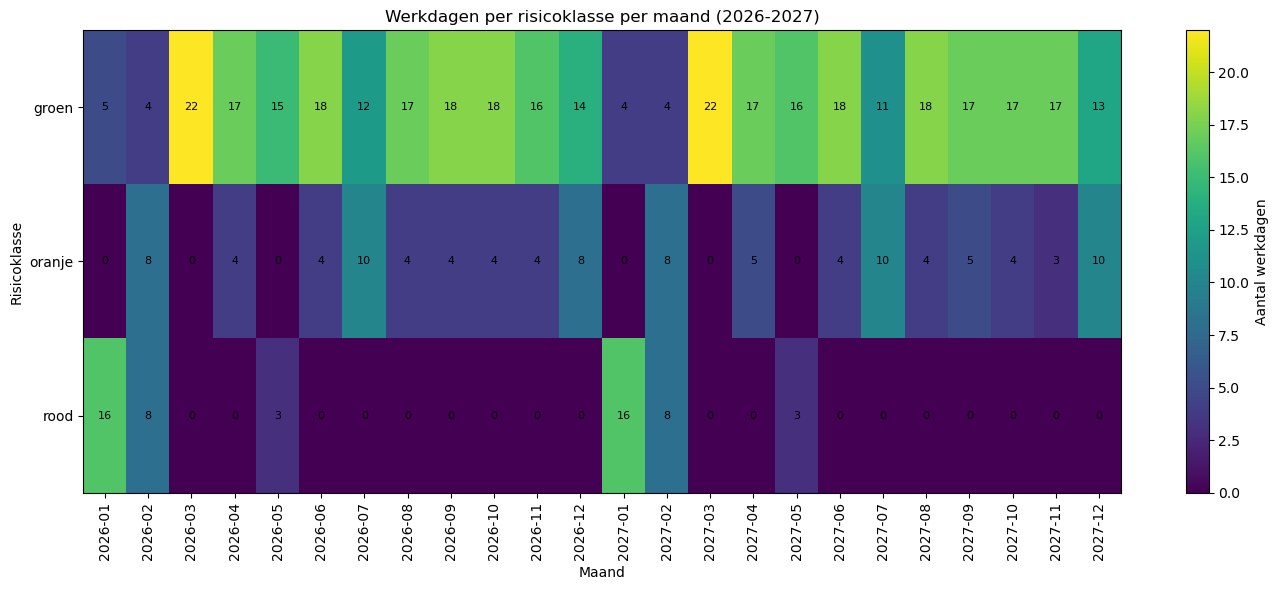

Heatmap opgeslagen: outputs/reports/risk_calendar_heatmap_2026_2027.png
Tabel opgeslagen: outputs/reports/risk_calendar_monthly_counts_2026_2027.csv


risk_level,year_month,groen,oranje,rood
0,2026-01,5,0,16
1,2026-02,4,8,8
2,2026-03,22,0,0
3,2026-04,17,4,0
4,2026-05,15,0,3
5,2026-06,18,4,0
6,2026-07,12,10,0
7,2026-08,17,4,0
8,2026-09,18,4,0
9,2026-10,18,4,0


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

calendar_path = Path("outputs/predictions/risk_calendar_2026_2027.csv")
if not calendar_path.exists():
    raise ValueError("Kalenderbestand ontbreekt. Run eerst cel 28.")

df_cal = pd.read_csv(calendar_path)
df_cal["date"] = pd.to_datetime(df_cal["date"], errors="coerce")
df_cal = df_cal.dropna(subset=["date"]).copy()
df_cal["year_month"] = df_cal["date"].dt.to_period("M").astype(str)

monthly_counts = (
    df_cal.groupby(["year_month", "risk_level"]).size()
    .unstack(fill_value=0)
    .reindex(columns=["groen", "oranje", "rood"], fill_value=0)
)

# Zorg voor volledige maandvolgorde
all_months = pd.period_range("2026-01", "2027-12", freq="M").astype(str)
monthly_counts = monthly_counts.reindex(all_months, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(monthly_counts.values.T, aspect="auto")

ax.set_title("Werkdagen per risicoklasse per maand (2026-2027)")
ax.set_xlabel("Maand")
ax.set_ylabel("Risicoklasse")
ax.set_xticks(range(len(monthly_counts.index)))
ax.set_xticklabels(monthly_counts.index, rotation=90)
ax.set_yticks(range(len(monthly_counts.columns)))
ax.set_yticklabels(monthly_counts.columns)

# Waardes in de heatmap
for i in range(monthly_counts.shape[0]):
    for j in range(monthly_counts.shape[1]):
        val = int(monthly_counts.iloc[i, j])
        ax.text(i, j, str(val), ha="center", va="center", fontsize=8, color="black")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Aantal werkdagen")
plt.tight_layout()
plt.show()

# Opslaan
report_img = Path("outputs/reports/risk_calendar_heatmap_2026_2027.png")
report_img.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(report_img, dpi=160, bbox_inches="tight")

monthly_counts_out = monthly_counts.reset_index().rename(columns={"index": "year_month"})
monthly_counts_out.to_csv("outputs/reports/risk_calendar_monthly_counts_2026_2027.csv", index=False)

print(f"Heatmap opgeslagen: {report_img}")
print("Tabel opgeslagen: outputs/reports/risk_calendar_monthly_counts_2026_2027.csv")
display(monthly_counts_out.head(12))

# Weeknummer-heatmap (week x weekdag)
Deze visualisatie toont per ISO-week en werkdag de risicoklasse.
Interpretatie:
- 0 = groen
- 1 = oranje
- 2 = rood

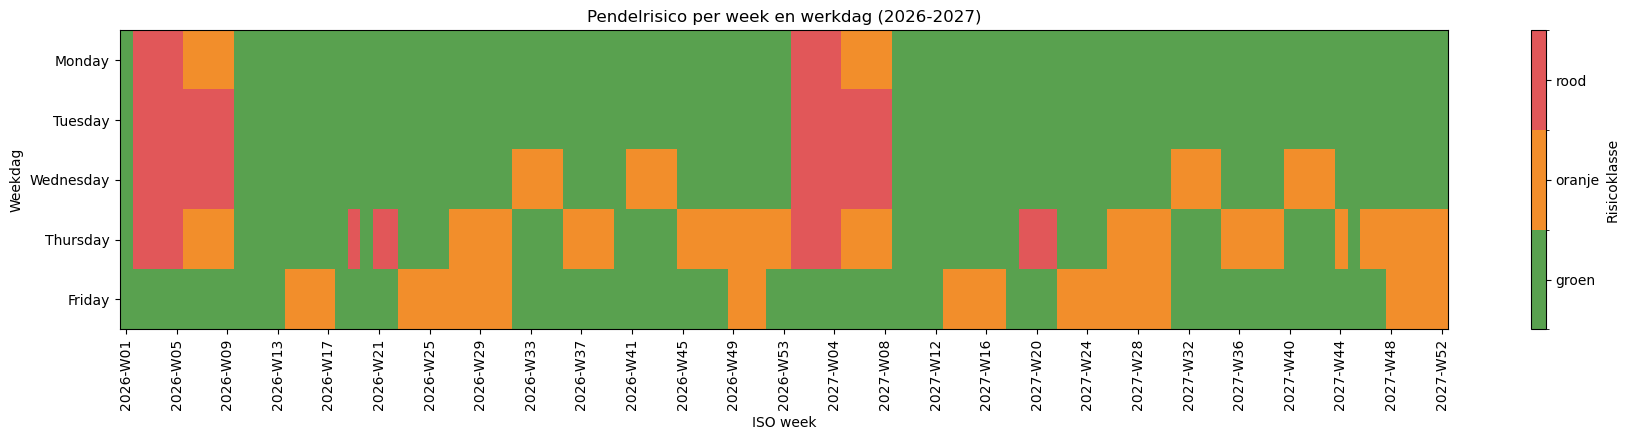

Weeknummer-heatmap opgeslagen: outputs/reports/risk_calendar_weekday_week_heatmap_2026_2027.png
Matrix opgeslagen: outputs/reports/risk_calendar_weekday_week_matrix_2026_2027.csv


week_key,weekday,2026-W01,2026-W02,2026-W03,2026-W04,2026-W05,2026-W06,2026-W07,2026-W08,2026-W09,...,2027-W43,2027-W44,2027-W45,2027-W46,2027-W47,2027-W48,2027-W49,2027-W50,2027-W51,2027-W52
0,Monday,0,2,2,2,2,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,Tuesday,0,2,2,2,2,2,2,2,2,...,0,0,0,0,0,0,0,0,0,0
2,Wednesday,0,2,2,2,2,2,2,2,2,...,1,0,0,0,0,0,0,0,0,0
3,Thursday,0,2,2,2,2,1,1,1,1,...,0,1,0,1,1,1,1,1,1,1
4,Friday,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,1,1


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from pathlib import Path

calendar_path = Path("outputs/predictions/risk_calendar_2026_2027.csv")
if not calendar_path.exists():
    raise ValueError("Kalenderbestand ontbreekt. Run eerst cel 28.")

df_w = pd.read_csv(calendar_path)
df_w["date"] = pd.to_datetime(df_w["date"], errors="coerce")
df_w = df_w.dropna(subset=["date"]).copy()

df_w["iso_year"] = df_w["date"].dt.isocalendar().year.astype(int)
df_w["iso_week"] = df_w["date"].dt.isocalendar().week.astype(int)
df_w["week_key"] = df_w["iso_year"].astype(str) + "-W" + df_w["iso_week"].astype(str).str.zfill(2)
df_w["weekday"] = df_w["date"].dt.day_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
df_w = df_w[df_w["weekday"].isin(weekday_order)].copy()

risk_to_num = {"groen": 0, "oranje": 1, "rood": 2}
df_w["risk_num"] = df_w["risk_level"].map(risk_to_num).fillna(0).astype(int)

week_order = sorted(df_w["week_key"].unique())
pivot = (
    df_w.pivot_table(index="weekday", columns="week_key", values="risk_num", aggfunc="max")
    .reindex(index=weekday_order, columns=week_order)
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(18, 4.5))
cmap = ListedColormap(["#59a14f", "#f28e2b", "#e15759"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, norm=norm)

ax.set_title("Pendelrisico per week en werkdag (2026-2027)")
ax.set_xlabel("ISO week")
ax.set_ylabel("Weekdag")
ax.set_yticks(range(len(weekday_order)))
ax.set_yticklabels(weekday_order)

step = 4
xticks = list(range(0, len(week_order), step))
if (len(week_order) - 1) not in xticks:
    xticks.append(len(week_order) - 1)
ax.set_xticks(xticks)
ax.set_xticklabels([week_order[i] for i in xticks], rotation=90)

# Legenda via colorbar
cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["groen", "oranje", "rood"])
cbar.set_label("Risicoklasse")

plt.tight_layout()
plt.show()

img_path = Path("outputs/reports/risk_calendar_weekday_week_heatmap_2026_2027.png")
img_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(img_path, dpi=160, bbox_inches="tight")

pivot_out = pivot.reset_index()
pivot_out.to_csv("outputs/reports/risk_calendar_weekday_week_matrix_2026_2027.csv", index=False)

print(f"Weeknummer-heatmap opgeslagen: {img_path}")
print("Matrix opgeslagen: outputs/reports/risk_calendar_weekday_week_matrix_2026_2027.csv")
display(pivot_out.head())

## 5) Snelle Run + Spreekscript (10 minuten)

Gebruik deze timing tijdens je presentatie. De codecel eronder geeft meteen de kernresultaten.

### 0:00 - 1:00 | Context en doel
- Traject: Gent -> Mechelen, aankomst tegen 09:00.
- Keuze tussen auto, trein of thuiswerken.
- Doel: dagelijks praktisch en datagedreven pendeladvies.

### 1:00 - 2:30 | Data en scope
- Historische weerdata vanaf 2021-01-01.
- Belgische werkdagfilter (weekdagen en feestdagen).
- Verkeerscontext via DATEX + afgeleide kenmerken.

### 2:30 - 4:00 | Modelaanpak
- Heuristisch risicomodel met features voor regen, wind, temperatuur, spitsdag en buffers.
- Score bepaalt aanbeveling: auto, trein of thuiswerken.
- Uitlegbaar model: elke beslissing heeft een duidelijke reden.

### 4:00 - 5:30 | Validatie en optimalisatie
- Rolling walk-forward backtest over tijdsblokken.
- Grid-search op modelparameters tegen proxy labels.
- Resultaat: stabiele prestaties en reproduceerbare tuning.

### 5:30 - 7:00 | Resultaten tonen (snelle run output)
- Gemiddelde accuracy en beste fold-accuracy.
- Laatste 10 dagelijkse pendeladviezen.
- Beste modelparameters uit optimalisatie.

### 7:00 - 8:30 | Risicokalender 2026-2027
- Dagen ingedeeld in groen, oranje, rood.
- Maandpatronen en weekpatronen zichtbaar in heatmaps.
- Praktische vraag: op welke periodes extra voorzichtig plannen.

### 8:30 - 9:30 | Conclusies voor besluitvorming
- Niet elke dag dezelfde modus: dynamisch advies werkt beter.
- Trein is vaak robuust op klassieke spitsdagen.
- Rode risicodagen zijn expliciet zichtbaar voor proactieve planning.

### 9:30 - 10:00 | Beperkingen en next steps
- Labels zijn proxy-gebaseerd, geen gemeten werkelijke reistijden.
- Next step: echte reisduur- en storingslabels integreren.
- Eventueel: probabilistisch model en realtime alerts.

### Tip voor live demo
- Run alleen de codecel onder deze markdown: die leest bestaande outputbestanden in en toont direct alle KPI's en tabellen.

## 5b) Backup Spreekscript (5 minuten)

Gebruik deze versie als je minder spreektijd krijgt. De codecel eronder blijft dezelfde snelle run.

### 0:00 - 0:45 | Doel
- Pendeladvies Gent -> Mechelen met aankomst om 09:00.
- Dagelijkse keuze: auto, trein of thuiswerken.

### 0:45 - 1:30 | Data
- Historische weerdata sinds 2021.
- Belgische werkdagfilter (zonder feestdagen).
- Verkeerscontext via DATEX-snapshots.

### 1:30 - 2:30 | Aanpak
- Uitlegbare heuristiek met regen, wind, temperatuur en weekdageffecten.
- Buffers toegevoegd om robuuster op tijd aan te komen.
- Adviesmodus gekozen op basis van totale verwachte reistijd en risico.

### 2:30 - 3:30 | Validatie
- Rolling backtest + parameteroptimalisatie via grid-search.
- Belangrijkste KPI's komen direct uit de snelle run-cel.

### 3:30 - 4:30 | Kernresultaten
- Stabiele modelprestatie en werkbare dagelijkse aanbevelingen.
- Risicokalender 2026-2027 met groen, oranje en rood.
- Heatmaps tonen duidelijk in welke periodes extra voorzichtig plannen nodig is.

### 4:30 - 5:00 | Afsluiting
- Beslislogica is praktisch inzetbaar voor dagelijkse planning.
- Belangrijkste beperking: evaluatie met proxy-labels.
- Volgende stap: valideren met echte reistijd- en storingsdata.

In [11]:
from pathlib import Path
import pandas as pd

paths = {
    "daily_recommendations": Path("outputs/recommendations/commute_daily_recommendations.csv"),
    "next_week_plan": Path("outputs/predictions/next_week_commute_plan_2026-06-01_2026-06-05.csv"),
    "risk_calendar": Path("outputs/predictions/risk_calendar_2026_2027.csv"),
    "monthly_counts": Path("outputs/reports/risk_calendar_monthly_counts_2026_2027.csv"),
    "month_heatmap": Path("outputs/reports/risk_calendar_heatmap_2026_2027.png"),
    "week_heatmap": Path("outputs/reports/risk_calendar_weekday_week_heatmap_2026_2027.png"),
    "best_params": Path("outputs/reports/optimized_model_best_params.csv"),
    "rolling_backtest": Path("outputs/reports/rolling_backtest_results.csv"),
}

missing = [k for k, p in paths.items() if not p.exists()]
if missing:
    print("Ontbrekende bestanden voor snelle run:")
    for m in missing:
        print(f"- {m}: {paths[m]}")
    print("Run eerst de volledige pipeline-secties om alle outputbestanden te genereren.")
else:
    daily = pd.read_csv(paths["daily_recommendations"])
    risk = pd.read_csv(paths["risk_calendar"])
    monthly = pd.read_csv(paths["monthly_counts"])
    params = pd.read_csv(paths["best_params"])
    backtest = pd.read_csv(paths["rolling_backtest"])

    # KPI's
    mean_test_acc = backtest["test_accuracy"].mean() if "test_accuracy" in backtest.columns else float("nan")
    best_test_acc = backtest["test_accuracy"].max() if "test_accuracy" in backtest.columns else float("nan")
    risk_counts = risk["risk_level"].value_counts().to_dict()

    print("=== Snelle Run KPI's ===")
    print(f"Gemiddelde backtest-accuracy: {mean_test_acc:.3f}")
    print(f"Beste fold-accuracy: {best_test_acc:.3f}")
    print(f"Risicodagen 2026-2027: groen={risk_counts.get('groen', 0)}, oranje={risk_counts.get('oranje', 0)}, rood={risk_counts.get('rood', 0)}")

    print("\nLaatste 10 pendeladviezen:")
    display(daily.tail(10))

    print("\nTop 12 maanden risicodistributie:")
    display(monthly.head(12))

    print("\nBeste modelparameters:")
    display(params)

    print("\nBelangrijkste rapportbestanden:")
    for k, p in paths.items():
        print(f"- {k}: {p}")

=== Snelle Run KPI's ===
Gemiddelde backtest-accuracy: 0.928
Beste fold-accuracy: 1.000
Risicodagen 2026-2027: groen=350, oranje=103, rood=54

Laatste 10 pendeladviezen:


,date,weekday,recommended_mode,recommended_departure_time,expected_arrival_time,expected_travel_time_minutes,auto_total_min,train_total_min,home_risk_score,reason
1353,2026-05-11,Monday,trein,07:41,09:00,63.2,82.275,78.194,0,stabiele pendelomstandigheden
1354,2026-05-12,Tuesday,trein,07:45,09:00,62.8,76.505,74.822,0,klassieke spitsdag
1355,2026-05-13,Wednesday,auto,07:55,09:00,54.3,64.340,72.232,0,stabiele pendelomstandigheden
1356,2026-05-15,Friday,auto,07:56,09:00,53.3,63.290,71.692,0,stabiele pendelomstandigheden
1357,2026-05-18,Monday,trein,07:46,09:00,61.4,73.585,73.358,0,stabiele pendelomstandigheden
1358,2026-05-19,Tuesday,trein,07:46,09:00,61.9,74.745,73.926,0,klassieke spitsdag
1359,2026-05-20,Wednesday,auto,07:53,09:00,56.2,66.160,73.168,0,stabiele pendelomstandigheden
1360,2026-05-21,Thursday,trein,07:46,09:00,61.7,74.360,73.728,0,klassieke spitsdag
1361,2026-05-22,Friday,auto,07:57,09:00,52.8,62.765,71.422,0,stabiele pendelomstandigheden
1362,2026-05-26,Tuesday,auto,07:47,09:00,57.8,72.820,72.936,0,klassieke spitsdag



Top 12 maanden risicodistributie:


,year_month,groen,oranje,rood
0,2026-01,5,0,16
1,2026-02,4,8,8
2,2026-03,22,0,0
3,2026-04,17,4,0
4,2026-05,15,0,3
5,2026-06,18,4,0
6,2026-07,12,10,0
7,2026-08,17,4,0
8,2026-09,18,4,0
9,2026-10,18,4,0



Beste modelparameters:


,auto_base,auto_mon,auto_tuethu,auto_rain,auto_wind,auto_cold,auto_heavy_rain,train_base,train_mon,train_tuethu,train_rain,train_wind,train_heavy_rain,train_storm,home_rain_thr,home_wind_thr,home_temp_thr,home_humidity_thr,home_score_thr,home_time_thr
0,48,3,5,1.4,0.3,7,3,56,1,2,0.7,0.2,4,5,2.5,42,-2,96,4,85



Belangrijkste rapportbestanden:
- daily_recommendations: outputs/recommendations/commute_daily_recommendations.csv
- next_week_plan: outputs/predictions/next_week_commute_plan_2026-06-01_2026-06-05.csv
- risk_calendar: outputs/predictions/risk_calendar_2026_2027.csv
- monthly_counts: outputs/reports/risk_calendar_monthly_counts_2026_2027.csv
- month_heatmap: outputs/reports/risk_calendar_heatmap_2026_2027.png
- week_heatmap: outputs/reports/risk_calendar_weekday_week_heatmap_2026_2027.png
- best_params: outputs/reports/optimized_model_best_params.csv
- rolling_backtest: outputs/reports/rolling_backtest_results.csv
